# Árvores de Decisão e Random Forest

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

Até aqui trabalhamos com modelos que olham para a **série e para o tempo**: o ARIMA/SARIMA olha para os próprios valores passados, e o Prophet ajusta curvas de tendência, sazonalidade e feriados. Nesta aula mudamos de família e também de forma de pensar o problema.

Uma **árvore de decisão** não sabe o que é tempo. Ela não conhece lag, não conhece estacionariedade e não faz diferenciação. O que ela faz é olhar uma **tabela de variáveis** (hora do dia, dia da semana, é feriado?, é dia de vencimento?) e aprender uma sequência de perguntas de sim ou não que separa horas de demanda alta de horas de demanda baixa. É por isso que, para usar árvores, o primeiro passo é **transformar a série temporal em uma tabela**, e é exatamente esse passo que abre a porta para incorporar quantas variáveis externas quisermos.

Esta aula é a base das duas seguintes. Como diz a apostila na Seção 5, **XGBoost e LightGBM são, no fundo, centenas ou milhares de árvores de decisão simples trabalhando em conjunto**. Não faz sentido estudar um ensemble de árvores sem entender antes o que é **uma** árvore, como ela aprende e por que ela sozinha não basta.

**Ao final desta aula você será capaz de:**

1. Explicar o que é uma árvore de decisão e identificar raiz, nó e folha em uma árvore treinada.
2. Calcular, na mão, a **redução de variância** de uma divisão candidata e entender por que o algoritmo escolhe justamente aquela pergunta.
3. Diagnosticar **overfitting** com a curva de erro de treino contra erro de teste e controlá-lo com `max_depth` e `min_samples_leaf`.
4. Explicar por que uma árvore isolada é **instável** e como o **bagging** corrige isso.
5. Treinar e interpretar um **Random Forest**, incluindo o erro out-of-bag e a importância das variáveis.

**Caso de estudo:** voltamos ao **volume de ligações na central de atendimento da operadora**, medido hora a hora, o mesmo processo das aulas anteriores. A diferença é que agora ele vem acompanhado de **variáveis operacionais** que nenhum dos modelos anteriores aproveitava bem: feriados, véspera de feriado, janela de vencimento de mensalidade e campanhas de comunicação (Seção 11.4 da apostila).

**Como usar este material:** execute as células na ordem, de cima para baixo. Depois de cada gráfico ou tabela há um bloco **Lendo o resultado**, que interpreta a saída ponto a ponto. Onde houver controles deslizantes, mova-os e observe o modelo ser retreinado na hora.


## 0. Preparação do ambiente

A célula abaixo garante as bibliotecas necessárias e define os padrões visuais. Rode uma vez e siga em frente.


In [1]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "scikit-learn", "ipywidgets"])

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

SEMENTE = 11
print("Ambiente pronto. Bibliotecas carregadas com sucesso.")

Ambiente pronto. Bibliotecas carregadas com sucesso.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## O laboratório da aula: a central de atendimento, com vida operacional

Como nas aulas anteriores, vamos **construir** a série em vez de baixá-la. A vantagem didática é a mesma: se somos nós que colocamos cada efeito dentro dos dados, sabemos exatamente o que a árvore **deveria** descobrir, e podemos verificar se ela descobriu.

A série cobre **1 ano inteiro de operação, hora a hora** (8.760 registros), e foi montada com seis ingredientes:

- um **nível base** com leve **tendência** de crescimento (a carteira aumenta ao longo do ano);
- o **ciclo diário** de 24 horas, com o perfil típico de call center (madrugada calma, pico de manhã, queda no almoço, segundo pico à tarde);
- o **ciclo semanal** de 7 dias (segunda cheia, fim de semana leve);
- o efeito da **janela de vencimento da mensalidade**, do dia 5 ao dia 9 de cada mês, que gera ligações sobre boleto e segunda via, mas **somente em horário comercial**;
- o efeito de **campanhas de comunicação** em massa (SMS ou e-mail sobre mudança de rede credenciada), que concentram ligações **no meio da manhã** por poucos dias;
- o efeito dos **feriados nacionais** e das **vésperas**, que derrubam o volume.

Repare em dois detalhes que serão o ponto central da aula. O efeito do vencimento só vale **dentro** do horário comercial, e o efeito da campanha só vale **entre 9h e 13h**. Ou seja, existem **interações** entre variáveis: o efeito de uma depende do valor da outra. Modelos aditivos como o Prophet têm dificuldade nativa com isso; árvores capturam interação de forma natural, porque cada pergunta é feita **dentro** do grupo já separado pelas perguntas anteriores.

> **Na prática**, no lugar da geração sintética você leria a base real da operadora com algo como `pd.read_csv('ligacoes_call_center.csv', parse_dates=['data_hora'], index_col='data_hora')`. Todo o restante do notebook funciona igual.


In [2]:
# Perfil relativo de ligacoes por HORA DO DIA (0h a 23h), formato de call center.
PERFIL_HORARIO = np.array([
    -8, -9, -9, -9, -8, -6,   # 0h a 5h   madrugada
    -3,  1,  5,  8,  9,  8,   # 6h a 11h  pico da manha
     3,  2,  7,  8,  6,  3,   # 12h a 17h queda no almoco e pico da tarde
    -1, -3, -4, -5, -6, -7    # 18h a 23h fim do expediente
], dtype=float)

# Perfil relativo por DIA DA SEMANA (0=segunda ... 6=domingo).
PERFIL_SEMANAL = np.array([3, 1, 0, 1, 2, -2, -3], dtype=float)

# Feriados nacionais de 2025 (inclui Carnaval, tratado como feriado na operacao).
FERIADOS = pd.to_datetime([
    "2025-01-01", "2025-03-03", "2025-03-04", "2025-04-18", "2025-04-21",
    "2025-05-01", "2025-06-19", "2025-09-07", "2025-10-12", "2025-11-02",
    "2025-11-15", "2025-11-20", "2025-12-25",
])

# Janelas de campanha de comunicacao em massa (dia corrido do ano, 4 dias cada).
JANELAS_CAMPANHA = np.concatenate([np.arange(40, 44), np.arange(150, 154), np.arange(318, 322)])

def gerar_ligacoes(dias=365, semente=SEMENTE):
    """Gera 1 ano de volume horario de ligacoes na central da operadora.

    Efeitos embutidos de proposito, para depois conferirmos se a arvore os encontra:
      - vencimento (dia 5 a 9) soma volume APENAS em horario comercial;
      - campanha soma volume APENAS entre 9h e 13h;
      - feriado e vespera reduzem o volume.
    """
    g = np.random.default_rng(semente)
    n = dias * 24
    indice = pd.date_range("2025-01-01", periods=n, freq="h")

    hora = indice.hour.to_numpy()
    dia_semana = indice.dayofweek.to_numpy()
    dia_mes = indice.day.to_numpy()
    dia_corrido = np.arange(n) // 24

    eh_feriado = np.isin(indice.normalize(), FERIADOS).astype(float)
    eh_vespera = np.isin(indice.normalize(), FERIADOS - pd.Timedelta(days=1)).astype(float)
    eh_vencimento = ((dia_mes >= 5) & (dia_mes <= 9)).astype(float)
    campanha = np.isin(dia_corrido, JANELAS_CAMPANHA).astype(float)

    horario_comercial = ((hora >= 8) & (hora <= 18)).astype(float)
    meio_da_manha = ((hora >= 9) & (hora <= 13)).astype(float)

    valor = (24 + 0.015 * dia_corrido                      # nivel + tendencia
             + PERFIL_HORARIO[hora]                        # ciclo diario
             + PERFIL_SEMANAL[dia_semana]                  # ciclo semanal
             + 7.0 * eh_vencimento * horario_comercial     # INTERACAO vencimento x hora
             + 9.0 * campanha * meio_da_manha              # INTERACAO campanha x hora
             - 11.0 * eh_feriado
             - 3.0 * eh_vespera
             + g.normal(0, 1.8, size=n))                   # ruido

    valor = np.clip(np.round(valor), 0, None)
    return pd.DataFrame({"n_ligacoes": valor}, index=indice)

ligacoes = gerar_ligacoes()

print(f"Observacoes: {len(ligacoes)}   |   de {ligacoes.index.min()} a {ligacoes.index.max()}")
print(f"Media: {ligacoes['n_ligacoes'].mean():.1f} ligacoes/hora   |   "
      f"minimo: {ligacoes['n_ligacoes'].min():.0f}   |   maximo: {ligacoes['n_ligacoes'].max():.0f}")
ligacoes.head()

Observacoes: 8760   |   de 2025-01-01 00:00:00 a 2025-12-31 23:00:00
Media: 26.4 ligacoes/hora   |   minimo: 2   |   maximo: 52


,n_ligacoes
2025-01-01 00:00:00,5.0
2025-01-01 01:00:00,6.0
2025-01-01 02:00:00,6.0
2025-01-01 03:00:00,3.0
2025-01-01 04:00:00,4.0


> **Lendo o resultado.** A base tem **8.760 linhas**, uma para cada hora de 1 de janeiro a 31 de dezembro de 2025, com **média de 26,4 ligações por hora** e valores indo de **2 a 52**. As primeiras linhas mostram a madrugada de 1 de janeiro, que é feriado nacional, e por isso trazem valores baixíssimos, entre 3 e 6 ligações por hora.
>
> Guarde a estrutura: por enquanto temos **uma única coluna** e um índice de tempo. Isso é suficiente para ARIMA e Prophet, mas **não** é suficiente para uma árvore. Uma árvore precisa de colunas para fazer perguntas, e é isso que vamos construir em seguida.


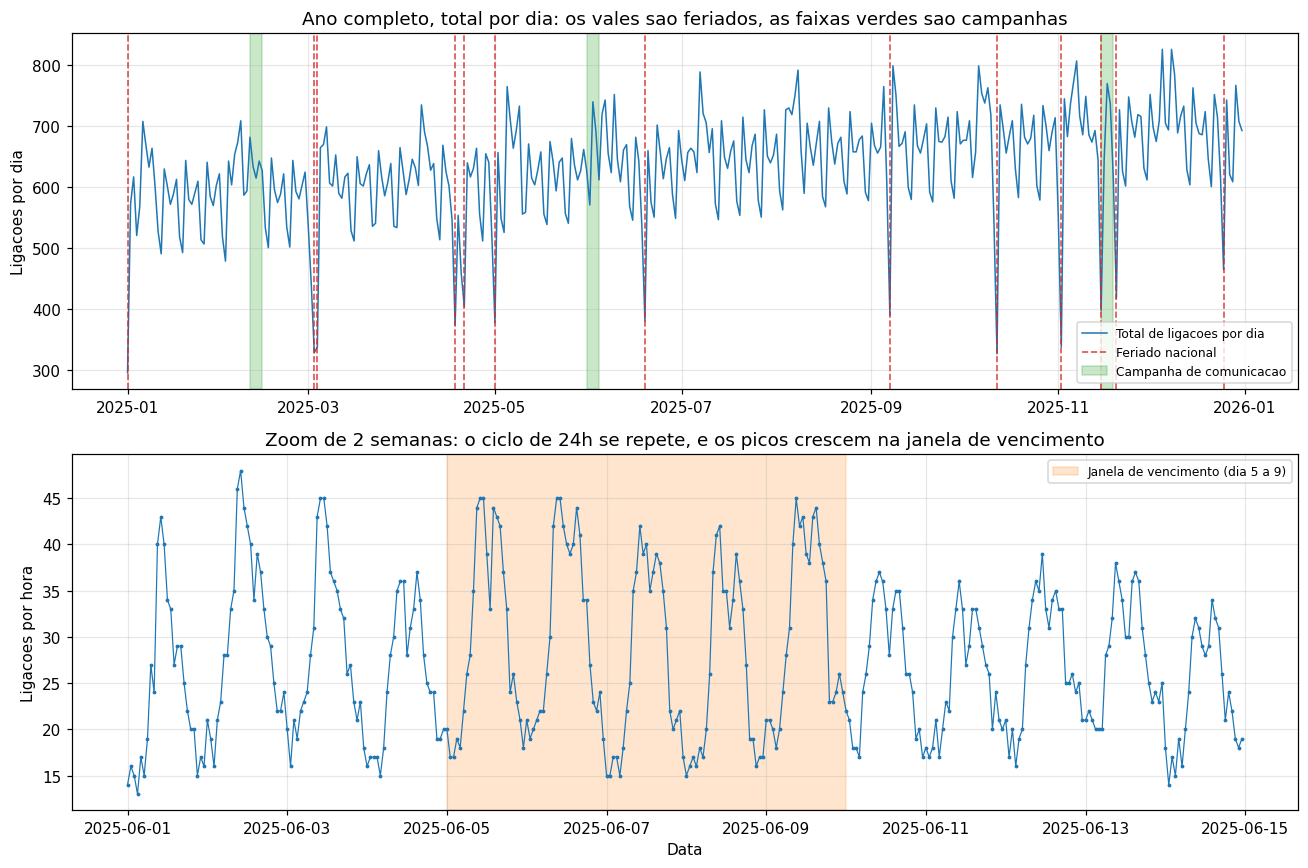

In [3]:
diario = ligacoes["n_ligacoes"].resample("D").sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Painel 1: total por dia no ano, com feriados e campanhas marcados
ax1.plot(diario.index, diario.values, color="#1f77b4", lw=1.0, label="Total de ligacoes por dia")
for i, d in enumerate(FERIADOS):
    ax1.axvline(d, color="#d62728", ls="--", lw=1.1, alpha=0.8,
                label="Feriado nacional" if i == 0 else None)
inicio_ano = ligacoes.index.normalize()[0]
for i, bloco in enumerate([JANELAS_CAMPANHA[:4], JANELAS_CAMPANHA[4:8], JANELAS_CAMPANHA[8:]]):
    ax1.axvspan(inicio_ano + pd.Timedelta(days=int(bloco[0])),
                inicio_ano + pd.Timedelta(days=int(bloco[-1]) + 1),
                color="#2ca02c", alpha=0.25,
                label="Campanha de comunicacao" if i == 0 else None)
ax1.set_title("Ano completo, total por dia: os vales sao feriados, as faixas verdes sao campanhas")
ax1.set_ylabel("Ligacoes por dia"); ax1.legend(loc="lower right", fontsize=8)

# Painel 2: zoom em 2 semanas que contem a janela de vencimento (dia 5 a 9)
zoom = ligacoes.loc["2025-06-01":"2025-06-14", "n_ligacoes"]
ax2.plot(zoom.index, zoom.values, color="#1f77b4", marker=".", ms=3, lw=0.8)
ax2.axvspan(pd.Timestamp("2025-06-05"), pd.Timestamp("2025-06-10"),
            color="#ff7f0e", alpha=0.20, label="Janela de vencimento (dia 5 a 9)")
ax2.set_title("Zoom de 2 semanas: o ciclo de 24h se repete, e os picos crescem na janela de vencimento")
ax2.set_ylabel("Ligacoes por hora"); ax2.set_xlabel("Data"); ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()

> **Lendo os gráficos.** O painel de cima mostra o **total por dia** ao longo do ano. Três coisas aparecem de uma vez: o nível **sobe suavemente** da esquerda para a direita (a tendência de crescimento da carteira), as linhas vermelhas tracejadas marcam os **feriados nacionais** e caem exatamente sobre os vales mais fundos do gráfico, e as faixas verdes marcam as **campanhas de comunicação**, que produzem pequenos platôs acima do nível vizinho.
>
> O painel de baixo é um zoom de duas semanas de junho, hora a hora. O **ciclo de 24 horas** se repete 14 vezes, e a faixa laranja destaca a **janela de vencimento** (dias 5 a 9): dentro dela, os **picos diurnos ficam visivelmente mais altos**, mas as madrugadas continuam iguais às das outras semanas. Esse é o retrato visual de uma **interação**: o efeito do vencimento só existe em certas horas do dia. É esse tipo de estrutura que a árvore vai aprender sem que ninguém precise avisá-la.


## Da série para a tabela: a engenharia de variáveis (Seção 11)

Este é o passo que muda tudo. Um modelo de árvore recebe uma matriz $X$ de **features** (variáveis explicativas) e um vetor $y$ com o alvo, e aprende uma função $\hat{y} = f(X)$. Não existe noção de ordem temporal dentro do modelo: se embaralhássemos as linhas, o resultado do treinamento seria o mesmo. Toda a informação de tempo tem que ser **escrita como coluna**.

As colunas que vamos criar seguem a Seção 11 da apostila:

| Feature              | Tipo         | O que captura                                                     |
| -------------------- | ------------ | ----------------------------------------------------------------- |
| `hora`               | temporal     | o ciclo diário: pico da manhã, almoço, segundo pico da tarde      |
| `dia_semana`         | temporal     | o ciclo semanal: segunda cheia, domingo vazio                     |
| `dia_mes`, `mes`     | temporal     | posição no mês e no ano                                           |
| `eh_fim_semana`      | calendário   | quebra de comportamento entre semana e fim de semana              |
| `eh_feriado`         | calendário   | queda forte de volume em feriado nacional                         |
| `eh_vespera_feriado` | calendário   | queda parcial no dia anterior ao feriado                          |
| `eh_vencimento`      | operacional  | janela de vencimento da mensalidade (dias 5 a 9)                  |
| `campanha`           | operacional  | janela de campanha de comunicação em massa                        |
| `temperatura`        | **controle** | variável **sem efeito real** sobre a série, incluída de propósito |

A última linha merece atenção. Incluímos `temperatura` sabendo que, nesta base sintética, ela **não tem nenhum efeito** sobre o volume de ligações. Ela está aqui como **variável de controle**, por dois motivos didáticos: primeiro, para mostrar mais adiante que a importância estimada pelo modelo a coloca perto do fim da fila, o que é a resposta correta; segundo, porque uma variável contínua e irrelevante é justamente o combustível do **overfitting**, e vamos ver isso acontecer com os nossos olhos.

Note também que **não** vamos criar features de lag (o valor de 24 horas atrás, por exemplo). Elas são poderosas e serão o assunto do notebook de engenharia de variáveis; aqui queremos isolar o comportamento da árvore usando apenas informação de **calendário e operação**, que é o que a operadora conhece com antecedência ao montar a escala de atendentes.


In [4]:
def construir_features(base):
    """Transforma o indice de tempo e o calendario da operadora em colunas de features."""
    idx = base.index
    dia_corrido = (idx.normalize() - idx.normalize()[0]).days

    # Temperatura media diaria: onda anual + ruido. Nao afeta a serie, e variavel de controle.
    g_temp = np.random.default_rng(99)
    temp_por_dia = 22 + 6 * np.sin(2 * np.pi * np.arange(366) / 365 + 1.2) + g_temp.normal(0, 2.5, 366)

    X = pd.DataFrame(index=idx)
    X["hora"] = idx.hour
    X["dia_semana"] = idx.dayofweek
    X["dia_mes"] = idx.day
    X["mes"] = idx.month
    X["eh_fim_semana"] = (idx.dayofweek >= 5).astype(int)
    X["eh_feriado"] = np.isin(idx.normalize(), FERIADOS).astype(int)
    X["eh_vespera_feriado"] = np.isin(idx.normalize(), FERIADOS - pd.Timedelta(days=1)).astype(int)
    X["eh_vencimento"] = ((idx.day >= 5) & (idx.day <= 9)).astype(int)
    X["campanha"] = np.isin(dia_corrido, JANELAS_CAMPANHA).astype(int)
    X["temperatura"] = np.round(temp_por_dia[dia_corrido], 1)
    return X

X = construir_features(ligacoes)
y = ligacoes["n_ligacoes"]

print(f"Matriz de features: {X.shape[0]} linhas x {X.shape[1]} colunas")
print(f"Alvo (y): volume de ligacoes na hora, media {y.mean():.1f}\n")
X.loc["2025-06-05 08:00":"2025-06-05 13:00"]

Matriz de features: 8760 linhas x 10 colunas
Alvo (y): volume de ligacoes na hora, media 26.4



,hora,dia_semana,dia_mes,mes,eh_fim_semana,eh_feriado,eh_vespera_feriado,eh_vencimento,campanha,temperatura
2025-06-05 08:00:00,8,3,5,6,0,0,0,1,0,17.9
2025-06-05 09:00:00,9,3,5,6,0,0,0,1,0,17.9
2025-06-05 10:00:00,10,3,5,6,0,0,0,1,0,17.9
2025-06-05 11:00:00,11,3,5,6,0,0,0,1,0,17.9
2025-06-05 12:00:00,12,3,5,6,0,0,0,1,0,17.9
2025-06-05 13:00:00,13,3,5,6,0,0,0,1,0,17.9


> **Lendo a tabela.** A série virou uma matriz de **8.760 linhas por 10 colunas**. Cada linha continua sendo uma hora de operação, mas agora ela se descreve sozinha: a linha das 10h de 5 de junho de 2025 diz que é `hora = 10`, `dia_semana = 3` (quinta), `dia_mes = 5`, `eh_vencimento = 1` e `eh_feriado = 0`.
>
> A partir daqui o modelo não precisa mais do índice de tempo. Ele vai perguntar coisas como "`hora` é menor ou igual a 6,5?" e "`eh_feriado` é igual a 1?". Toda a informação temporal está codificada nas colunas, e é por isso que essa família de modelos aceita, sem nenhuma cerimônia, **quantas variáveis externas você tiver**: basta acrescentar mais colunas.


### Separação treino e teste: sempre no tempo (Seção 12.2)

Um erro grave em previsão de séries temporais é separar treino e teste de forma **aleatória**. Se sortearmos linhas, o modelo vai treinar com horas de dezembro e ser testado em horas de novembro, ou seja, vai usar o **futuro para prever o passado**. O erro medido fica otimista e não representa nada da operação real.

A separação correta é **cronológica**, chamada de _holdout_ temporal: treinamos com o passado e avaliamos no futuro, exatamente como o modelo será usado. Aqui vamos treinar com **janeiro a outubro (10 meses)** e testar em **novembro e dezembro (2 meses)**, um período que, de propósito, contém **4 feriados nacionais** e **1 janela de campanha**, para que o teste seja realmente exigente.


TREINO:  7296 horas   (2025-01-01 a 2025-10-31)   media 26.0
TESTE :  1464 horas   (2025-11-01 a 2025-12-31)   media 28.2

Feriados dentro do teste : 4 dias
Dias de campanha no teste: 4 dias


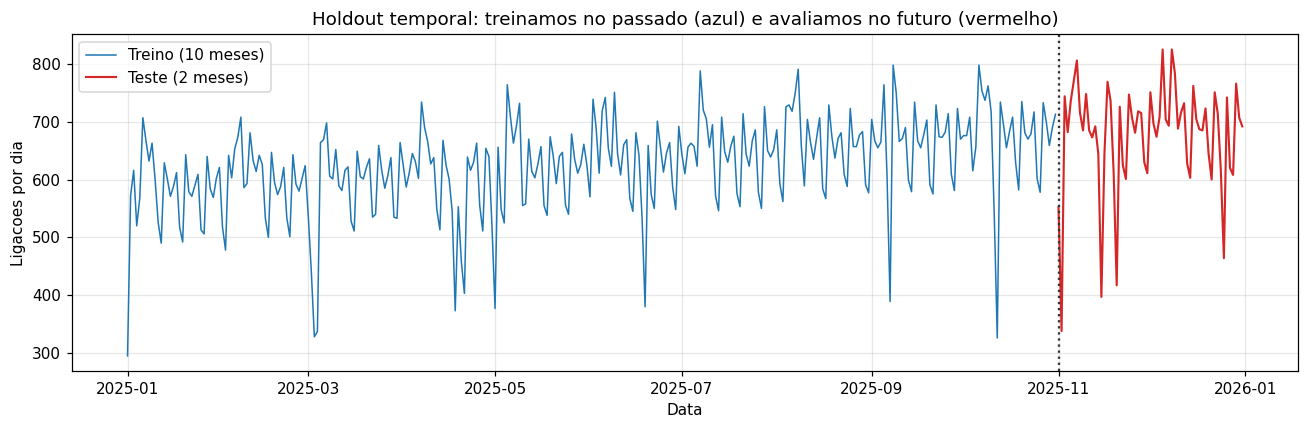

In [5]:
CORTE_TREINO = "2025-10-31 23:00"
CORTE_TESTE = "2025-11-01"

X_treino, X_teste = X.loc[:CORTE_TREINO], X.loc[CORTE_TESTE:]
y_treino, y_teste = y.loc[:CORTE_TREINO], y.loc[CORTE_TESTE:]

print(f"TREINO: {len(X_treino):5d} horas   ({y_treino.index.min().date()} a {y_treino.index.max().date()})"
      f"   media {y_treino.mean():.1f}")
print(f"TESTE : {len(X_teste):5d} horas   ({y_teste.index.min().date()} a {y_teste.index.max().date()})"
      f"   media {y_teste.mean():.1f}")
print()
print(f"Feriados dentro do teste : {int(X_teste['eh_feriado'].sum() / 24)} dias")
print(f"Dias de campanha no teste: {int(X_teste['campanha'].sum() / 24)} dias")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_treino.resample("D").sum(), color="#1f77b4", lw=1.0, label="Treino (10 meses)")
ax.plot(y_teste.resample("D").sum(), color="#d62728", lw=1.4, label="Teste (2 meses)")
ax.axvline(pd.Timestamp(CORTE_TESTE), color="#333333", ls=":", lw=1.5)
ax.set_title("Holdout temporal: treinamos no passado (azul) e avaliamos no futuro (vermelho)")
ax.set_ylabel("Ligacoes por dia"); ax.set_xlabel("Data"); ax.legend()
plt.tight_layout(); plt.show()

> **Lendo o resultado.** Ficamos com **7.296 horas de treino** (janeiro a outubro, média de 26,0 ligações/h) e **1.464 horas de teste** (novembro e dezembro, média de 28,2 ligações/h). O teste tem média mais alta porque a tendência de crescimento continua correndo, o que é uma dificuldade honesta: o modelo terá que prever um patamar que ele nunca viu no treino.
>
> O gráfico deixa a divisão explícita, com a linha pontilhada marcando o corte. Dentro do vermelho estão **4 feriados** (Finados, Proclamação da República, Consciência Negra e Natal) e **4 dias de campanha**, ou seja, o período de avaliação não é um trecho fácil e rotineiro. Nenhuma informação de novembro ou dezembro entra no treinamento em nenhum momento do notebook.


## 5.1 O que é uma árvore de decisão

> **Definição.** Uma **árvore de decisão** é uma sequência de perguntas de sim ou não, organizadas em estrutura hierárquica, que particiona os dados em grupos cada vez mais homogêneos até chegar a uma previsão.

O vocabulário é o de uma árvore genealógica de cabeça para baixo:

- a **raiz** (_root_) é a primeira pergunta, feita com **todos** os dados;
- cada **nó** (_node_) interno é uma nova pergunta, feita apenas com os dados que chegaram até ali;
- cada **folha** (_leaf_) é um ponto final, sem mais perguntas, e guarda o **valor previsto** para qualquer observação que caia nela. Em regressão, esse valor é simplesmente a **média do alvo** entre as observações de treino que terminaram naquela folha.

Vamos treinar a menor árvore possível que ainda seja interessante: **profundidade 2**, ou seja, no máximo duas perguntas entre a raiz e qualquer folha. Com isso ela pode ter no máximo 4 folhas. É pequena o bastante para desenharmos inteira e lermos com o dedo.


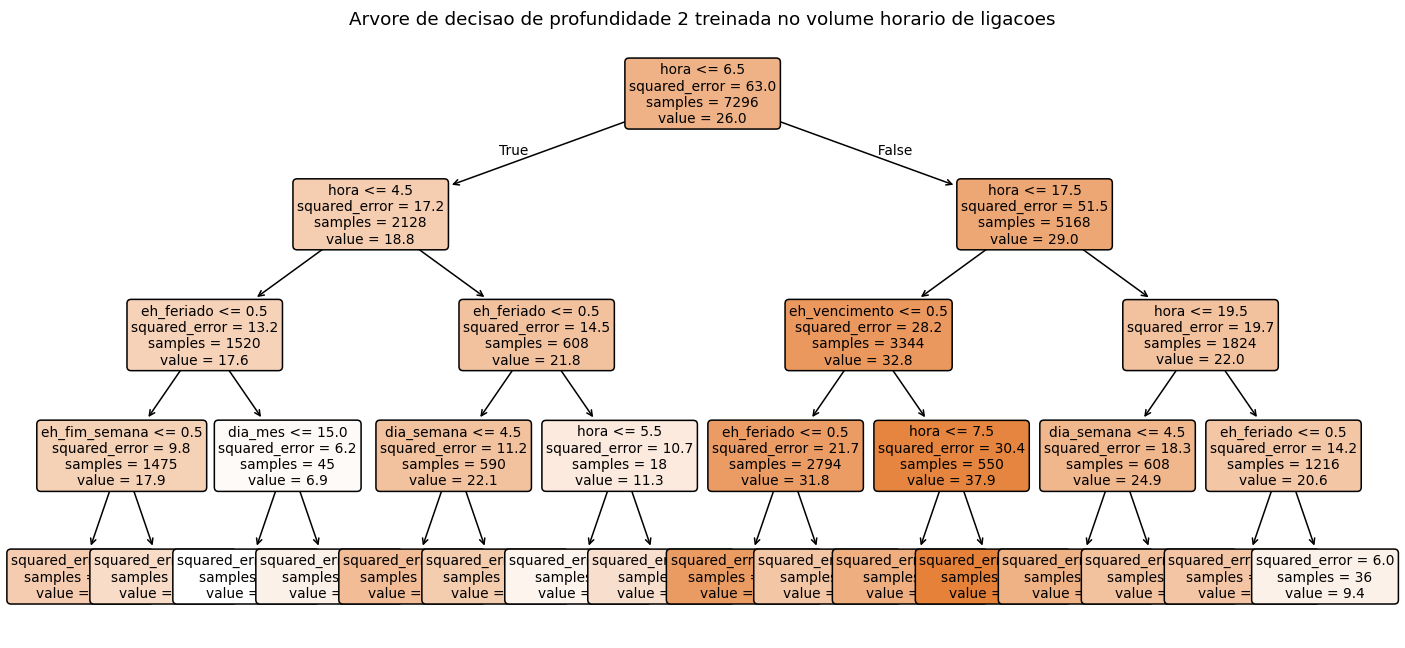

Numero de folhas: 16


In [6]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

arvore_rasa = DecisionTreeRegressor(max_depth=4, random_state=42)
arvore_rasa.fit(X_treino, y_treino)

fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(arvore_rasa, feature_names=list(X_treino.columns), filled=True, rounded=True,
          precision=1, fontsize=9, ax=ax, impurity=True)
ax.set_title("Arvore de decisao de profundidade 2 treinada no volume horario de ligacoes", fontsize=12)
plt.tight_layout(); plt.show()

print(f"Numero de folhas: {arvore_rasa.get_n_leaves()}")

> **Lendo a árvore.** Leia de cima para baixo, sempre indo para a **esquerda quando a resposta é sim** e para a direita quando é não.
>
> - A **raiz** pergunta `hora <= 6.5`, isto é, "estamos na madrugada?". Ela contém todas as **7.296** horas de treino, com `value = 26.0` (a média geral) e `squared_error = 63.0` (a variância do alvo).
> - Indo para a **esquerda** (madrugada), a árvore pergunta de novo sobre a hora, `hora <= 4.5`, e chega a duas folhas: **17,6 ligações/h** para as horas de 0h a 4h e **21,8** para 5h e 6h.
> - Indo para a **direita** (dia), ela pergunta `hora <= 17.5` e chega às folhas de **32,8 ligações/h** (das 7h às 17h, o corpo do expediente) e **22,0** (das 18h às 23h).
>
> Três leituras importantes. Primeiro, a árvore escolheu perguntar sobre `hora` **três vezes**, ignorando as outras nove colunas: ela julgou que a hora do dia é, de longe, a variável mais informativa, e vamos confirmar isso numericamente na Seção 5.2. Segundo, o `squared_error` **cai** de 63,0 na raiz para valores muito menores nas folhas: é essa queda que a árvore está maximizando. Terceiro, esse modelo já é utilizável: ele responde "quantos atendentes preciso?" com quatro números, um para cada faixa de hora, e qualquer gestor entende a regra sem saber nada de estatística.


In [7]:
print(export_text(arvore_rasa, feature_names=list(X_treino.columns), decimals=1))

|--- hora <= 6.5
|   |--- hora <= 4.5
|   |   |--- eh_feriado <= 0.5
|   |   |   |--- eh_fim_semana <= 0.5
|   |   |   |   |--- value: [19.1]
|   |   |   |--- eh_fim_semana >  0.5
|   |   |   |   |--- value: [15.0]
|   |   |--- eh_feriado >  0.5
|   |   |   |--- dia_mes <= 15.0
|   |   |   |   |--- value: [5.7]
|   |   |   |--- dia_mes >  15.0
|   |   |   |   |--- value: [9.4]
|   |--- hora >  4.5
|   |   |--- eh_feriado <= 0.5
|   |   |   |--- dia_semana <= 4.5
|   |   |   |   |--- value: [23.3]
|   |   |   |--- dia_semana >  4.5
|   |   |   |   |--- value: [19.3]
|   |   |--- eh_feriado >  0.5
|   |   |   |--- hora <= 5.5
|   |   |   |   |--- value: [8.7]
|   |   |   |--- hora >  5.5
|   |   |   |   |--- value: [14.0]
|--- hora >  6.5
|   |--- hora <= 17.5
|   |   |--- eh_vencimento <= 0.5
|   |   |   |--- eh_feriado <= 0.5
|   |   |   |   |--- value: [32.1]
|   |   |   |--- eh_feriado >  0.5
|   |   |   |   |--- value: [20.7]
|   |   |--- eh_vencimento >  0.5
|   |   |   |--- hora <

> **Lendo as regras.** Esta é a mesma árvore em texto, e é assim que ela costuma ir para uma reunião de operação. Traduzida para português corrido, a regra aprendida é:
>
> - entre **0h e 4h**, prever **17,6** ligações por hora;
> - às **5h e 6h**, prever **21,8**;
> - entre **7h e 17h**, prever **32,8**;
> - entre **18h e 23h**, prever **22,0**.
>
> Essa transparência é uma vantagem real das árvores sobre a LSTM e, em boa medida, sobre o ARIMA: a previsão é um conjunto de regras auditáveis, não um coeficiente abstrato. A limitação também já está visível: com apenas 4 valores possíveis, o modelo trata as 10h e as 15h como se fossem idênticas, e ignora completamente feriado, fim de semana e vencimento. É pouca resolução, e resolver isso significa deixar a árvore crescer.


## 5.2 Como uma árvore aprende: o critério de divisão

A pergunta central de qualquer algoritmo de árvore é: **dado um conjunto de dados e um conjunto de features candidatas, qual pergunta fazer primeiro?** A resposta não tem nada de subjetivo, é puramente estatística.

Em problemas de **regressão**, como prever um volume de ligações, o critério é a **redução de variância** (equivalente à redução do erro quadrático médio). Para uma divisão candidata que separa um nó com $n$ observações em um grupo esquerdo com $n_E$ e um direito com $n_D$, define-se:

$$ \Delta = \underbrace{\mathrm{Var}(y)}_{\text{variância antes}} \; - \; \underbrace{\left( \frac{n_E}{n}\,\mathrm{Var}(y_E) \; + \; \frac{n_D}{n}\,\mathrm{Var}(y_D) \right)}_{\text{variância depois, ponderada pelo tamanho}} $$

O algoritmo testa, por **força bruta**, todas as features e todos os limiares de corte possíveis, calcula $\Delta$ para cada combinação e escolhe a que der o **maior** valor. Depois repete o mesmo procedimento dentro de cada grupo formado, e dentro dos grupos dos grupos, e assim por diante. Esse procedimento se chama **divisão recursiva binária** (_recursive binary splitting_) e foi formalizado por Breiman et al. (1984) sob a sigla **CART**, que segue sendo a base conceitual das árvores internas do XGBoost e do LightGBM.

Para regressão o critério é variância; para **classificação** (prever uma categoria, e não um número) o critério muda para **impureza de Gini** ou **entropia**, que medem o quão misturadas estão as classes dentro do grupo. Como previsão de demanda é regressão, é a variância que nos interessa aqui.

Vamos fazer a conta na mão para a feature `hora`, testando os 23 limiares possíveis, e ver se chegamos ao mesmo `hora <= 6.5` que o scikit-learn escolheu.


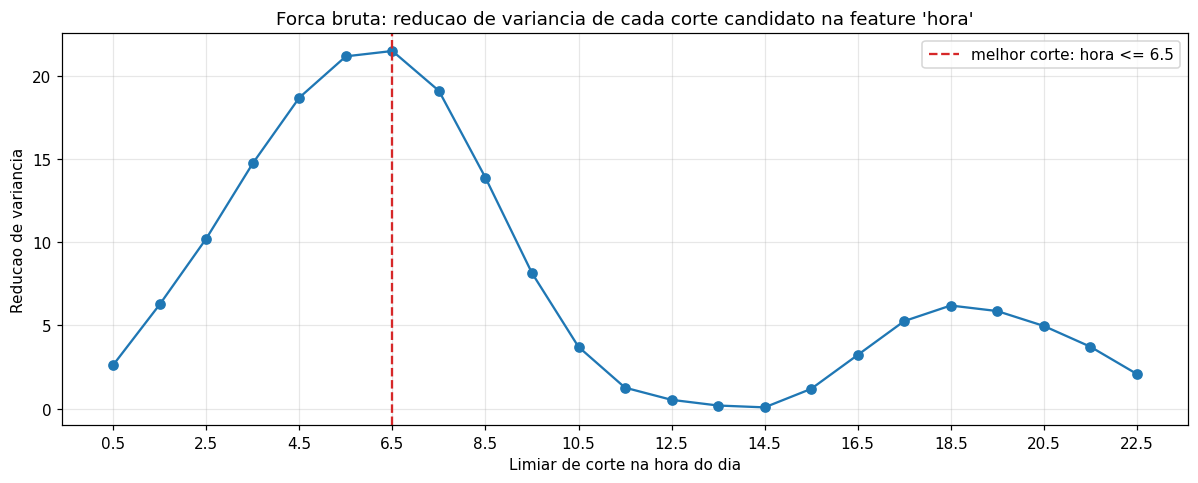

Variancia do alvo antes de qualquer divisao : 62.99
Melhor corte encontrado na mao              : hora <= 6.5
Reducao de variancia nesse corte            : 21.47  (34.1% da variancia total)
Corte escolhido pelo scikit-learn na raiz   : hora <= 6.5


In [8]:
def reducao_de_variancia(coluna, limiar):
    """Calcula o ganho (reducao de variancia ponderada) de uma divisao candidata no no raiz."""
    valores = X_treino[coluna].values
    esquerda = y_treino.values[valores <= limiar]
    direita = y_treino.values[valores > limiar]
    if len(esquerda) == 0 or len(direita) == 0:
        return 0.0
    n = len(y_treino)
    depois = (len(esquerda) / n) * np.var(esquerda) + (len(direita) / n) * np.var(direita)
    return np.var(y_treino.values) - depois

var_antes = np.var(y_treino.values)
limiares = np.arange(0, 23) + 0.5
ganhos = np.array([reducao_de_variancia("hora", L) for L in limiares])
melhor = limiares[int(np.argmax(ganhos))]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(limiares, ganhos, marker="o", color="#1f77b4")
ax.axvline(melhor, color="#d62728", ls="--", lw=1.5,
           label=f"melhor corte: hora <= {melhor}")
ax.set_title("Forca bruta: reducao de variancia de cada corte candidato na feature 'hora'")
ax.set_xlabel("Limiar de corte na hora do dia"); ax.set_ylabel("Reducao de variancia")
ax.set_xticks(np.arange(0.5, 23, 2)); ax.legend()
plt.tight_layout(); plt.show()

print(f"Variancia do alvo antes de qualquer divisao : {var_antes:.2f}")
print(f"Melhor corte encontrado na mao              : hora <= {melhor}")
print(f"Reducao de variancia nesse corte            : {ganhos.max():.2f}  "
      f"({100 * ganhos.max() / var_antes:.1f}% da variancia total)")
print(f"Corte escolhido pelo scikit-learn na raiz   : "
      f"{X_treino.columns[arvore_rasa.tree_.feature[0]]} <= {arvore_rasa.tree_.threshold[0]:.1f}")

> **Lendo o gráfico.** Cada ponto é um corte candidato na hora do dia, e a altura é o quanto aquele corte reduz a variância do volume de ligações. A curva tem **forma de sino com o topo bem definido em `hora <= 6.5`**, que produz uma redução de **21,47** contra uma variância total de **62,99**, ou seja, **34,1% da variabilidade da série explicada por uma única pergunta**.
>
> Repare que a curva não é plana: cortar em `hora <= 0.5` ou em `hora <= 22.5` reduz pouquíssimo, porque separa um punhado de observações contra todas as outras. O ganho máximo aparece onde a fronteira coincide com uma **quebra real de comportamento** da operação, a virada da madrugada para o expediente. A árvore não sabe o que é um call center; ela apenas encontrou, na estatística, o mesmo ponto que qualquer supervisor da central identificaria por experiência.
>
> A última linha confirma que a nossa conta artesanal chegou **exatamente** ao mesmo corte que o `DecisionTreeRegressor`: `hora <= 6.5`. Não há mágica dentro da biblioteca, apenas essa busca repetida muitas vezes.


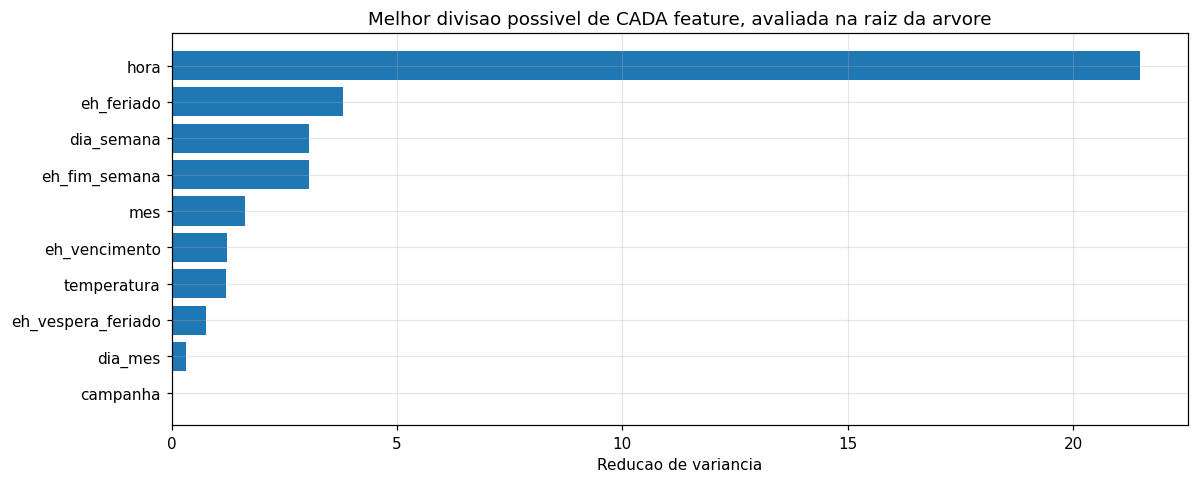

,feature,melhor_limiar,reducao_variancia,% da variancia
0,hora,6.5,21.474,34.1
1,eh_feriado,0.5,3.804,6.0
2,dia_semana,4.5,3.044,4.8
3,eh_fim_semana,0.5,3.044,4.8
4,mes,5.5,1.630,2.6
5,eh_vencimento,0.5,1.225,1.9
6,temperatura,24.1,1.205,1.9
7,eh_vespera_feriado,0.5,0.760,1.2
8,dia_mes,4.5,0.321,0.5
9,campanha,0.5,0.029,0.0


In [9]:
resumo = []
for coluna in X_treino.columns:
    valores_unicos = np.unique(X_treino[coluna].values)
    if len(valores_unicos) < 2:
        continue
    candidatos = (valores_unicos[:-1] + valores_unicos[1:]) / 2
    if len(candidatos) > 200:                      # limita a busca em features continuas
        candidatos = np.quantile(candidatos, np.linspace(0, 1, 200))
    ganho, limiar = max((reducao_de_variancia(coluna, L), L) for L in candidatos)
    resumo.append({"feature": coluna, "melhor_limiar": round(float(limiar), 1),
                   "reducao_variancia": round(float(ganho), 3),
                   "% da variancia": round(100 * ganho / var_antes, 1)})

resumo = pd.DataFrame(resumo).sort_values("reducao_variancia", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(resumo["feature"][::-1], resumo["reducao_variancia"][::-1], color="#1f77b4")
ax.set_title("Melhor divisao possivel de CADA feature, avaliada na raiz da arvore")
ax.set_xlabel("Reducao de variancia")
plt.tight_layout(); plt.show()

resumo

> **Lendo o gráfico e a tabela.** Aqui está a disputa da primeira pergunta, feature por feature. Cada barra mostra o melhor que aquela variável conseguiria fazer **se fosse escolhida para a raiz**.
>
> - **`hora`** ganha com folga: redução de **21,47** (34,1% da variância). Nenhuma outra chega perto.
> - **`eh_feriado`** vem em segundo, com **3,80** (6,0%), seguida de **`dia_semana`** e **`eh_fim_semana`**, ambas com **3,04** (4,8%). Faz sentido que empatem, já que `eh_fim_semana` é praticamente a mesma pergunta que `dia_semana <= 4.5`.
> - **`eh_vencimento`** aparece com **1,23** (1,9%) e **`campanha`** com apenas **0,03**.
>
> Uma linha dessa tabela merece um alerta: a variável de controle **`temperatura`**, que não tem efeito nenhum sobre a série, aparece com **1,21**, praticamente empatada com `eh_vencimento`, que tem efeito real. O motivo é que `temperatura` é **contínua** e portanto oferece centenas de limiares de corte candidatos; com tantas tentativas, alguma delas acaba separando o ruído por sorte. Guarde esse detalhe, porque ele volta quando discutirmos a importância das variáveis.
>
> Duas conclusões, e a segunda é a mais importante. A primeira é que a árvore escolhe `hora` para a raiz porque **é o melhor primeiro movimento**, e não por qualquer preferência do algoritmo. A segunda é que `campanha` parecer irrelevante **neste ranking é uma armadilha de interpretação**: a campanha só age em 12 dias do ano e apenas entre 9h e 13h, então ela quase não move a variância do conjunto **inteiro**. Isso não significa que ela seja inútil; significa que ela é útil **dentro de um subgrupo específico**, e a árvore só vai descobrir isso depois de já ter separado as horas do dia. É exatamente essa a mecânica que permite às árvores capturarem **interações** que um modelo aditivo não captura.


### Uma consequência importante: a árvore prevê em degraus

Antes de crescer a árvore, vale entender a **forma** da função que ela produz. Como cada folha devolve **um único número**, a previsão de uma árvore é sempre uma **função constante por partes**, uma escada. Ela nunca produz uma curva suave como a sazonalidade de Fourier do Prophet.

Isso tem duas implicações práticas. A boa: a árvore não assume linearidade nenhuma, e capta quebras abruptas (a virada do expediente, o efeito de um feriado) melhor do que qualquer modelo linear. A ruim: para representar uma transição suave, ela precisa de **muitos degraus**, e cada degrau custa uma divisão. E há um limite estrutural, que motiva os próximos módulos: uma árvore **não extrapola**. Se a demanda futura subir acima de tudo que ela viu no treino, a previsão fica presa no valor da folha mais alta.

O gráfico abaixo mostra o perfil real de uma quarta-feira comum contra a previsão de três árvores de profundidades diferentes.


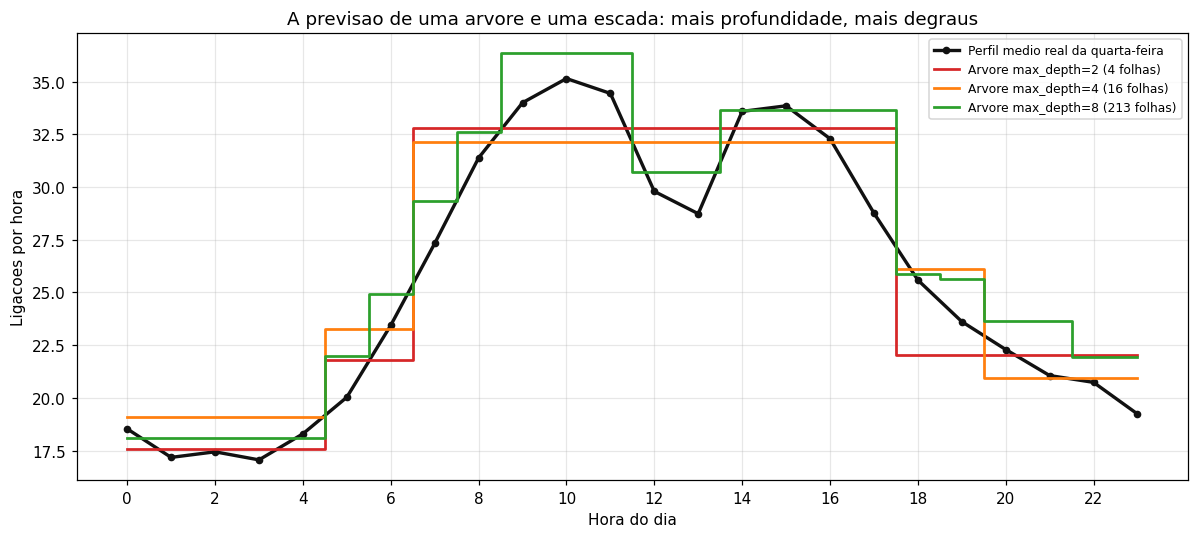

In [10]:
# Monta uma quarta-feira "comum" (sem feriado, sem campanha, fora da janela de vencimento)
def cenario_quarta_comum():
    linhas = pd.DataFrame({"hora": np.arange(24)})
    linhas["dia_semana"] = 2          # quarta-feira
    linhas["dia_mes"] = 18
    linhas["mes"] = 6
    linhas["eh_fim_semana"] = 0
    linhas["eh_feriado"] = 0
    linhas["eh_vespera_feriado"] = 0
    linhas["eh_vencimento"] = 0
    linhas["campanha"] = 0
    linhas["temperatura"] = float(np.median(X_treino["temperatura"]))
    return linhas[list(X_treino.columns)]

cenario = cenario_quarta_comum()

# Perfil medio real observado nas quartas-feiras comuns do treino
mascara = ((X_treino["dia_semana"] == 2) & (X_treino["eh_feriado"] == 0) &
           (X_treino["eh_vencimento"] == 0) & (X_treino["campanha"] == 0))
perfil_real = y_treino[mascara].groupby(X_treino.loc[mascara, "hora"]).mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(perfil_real.index, perfil_real.values, color="#111111", lw=2.2, marker="o", ms=4,
        label="Perfil medio real da quarta-feira")
for prof, cor in zip([2, 4, 8], ["#d62728", "#ff7f0e", "#2ca02c"]):
    modelo = DecisionTreeRegressor(max_depth=prof, random_state=SEMENTE).fit(X_treino, y_treino)
    ax.step(np.arange(24), modelo.predict(cenario), where="mid", lw=1.8, color=cor,
            label=f"Arvore max_depth={prof} ({modelo.get_n_leaves()} folhas)")
ax.set_title("A previsao de uma arvore e uma escada: mais profundidade, mais degraus")
ax.set_xlabel("Hora do dia"); ax.set_ylabel("Ligacoes por hora")
ax.set_xticks(range(0, 24, 2)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Lendo o gráfico.** A linha preta é o perfil médio real de uma quarta-feira comum: sobe da madrugada, faz o pico da manhã, cai no almoço, recupera à tarde e desce à noite. As três escadas coloridas são as previsões de árvores cada vez mais profundas.
>
> - A árvore de **profundidade 2** (vermelha, 4 folhas) é uma escada grosseira de quatro patamares. Ela acerta a ideia geral ("de dia é mais alto do que de madrugada") e erra tudo o que é detalhe: para ela, a queda do almoço não existe.
> - A de **profundidade 4** (laranja, 16 folhas) já desenha um degrau para a manhã e outro para a tarde, e começa a insinuar o vale do almoço.
> - A de **profundidade 8** (verde, 213 folhas) acompanha a linha preta de perto, hora por hora, incluindo o vale do meio-dia.
>
> A lição visual é que **profundidade é resolução**. Cada nível a mais dobra o número potencial de degraus e deixa o modelo copiar detalhes mais finos da curva. Isso soa como uma boa notícia até a próxima seção, quando descobrimos que copiar detalhe **fino demais** significa copiar o ruído.


## 5.3 Profundidade, overfitting e poda

Se o algoritmo continuar dividindo sem limite, ele para somente quando cada folha contiver **uma única observação**. Nesse ponto o erro no conjunto de treino é **exatamente zero**, porque cada linha tem a sua própria folha guardando o seu próprio valor. Isso parece perfeito e é, na verdade, o pior cenário: o modelo **memorizou o ruído** daquela amostra em vez de aprender o padrão. Esse fenômeno se chama **overfitting** (sobreajuste), e a sua marca registrada é a **divergência** entre o erro no treino e o erro em dados novos.

O controle é feito por hiperparâmetros que limitam o crescimento, o que se chama **pré-poda**:

| Hiperparâmetro      | O que faz                                                                 |
| ------------------- | ------------------------------------------------------------------------- |
| `max_depth`         | profundidade máxima: número de perguntas em sequência da raiz até a folha |
| `min_samples_leaf`  | mínimo de observações que cada folha precisa conter                       |
| `min_samples_split` | mínimo de observações em um nó para que ele ainda possa ser dividido      |

Existe também a **poda posterior** (_post-pruning_): deixar a árvore crescer livremente e depois remover nós de baixo para cima, sempre que a remoção não piorar de forma relevante o desempenho em um conjunto de validação. O scikit-learn oferece uma versão disso pelo parâmetro `ccp_alpha`, mas na prática o controle por pré-poda é mais usado por ser computacionalmente mais simples.

A célula abaixo produz o gráfico mais importante de toda esta aula: o erro de treino e o erro de teste em função da profundidade.


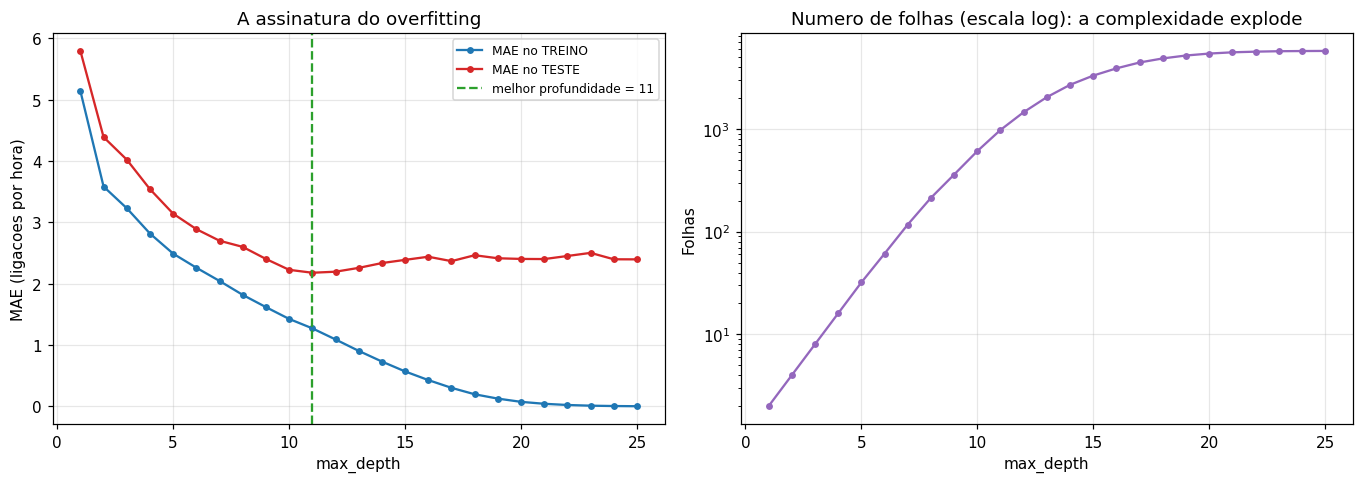

max_depth=  1 | folhas=    2 | MAE treino= 5.14 | MAE teste= 5.79
max_depth=  2 | folhas=    4 | MAE treino= 3.58 | MAE teste= 4.39
max_depth=  4 | folhas=   16 | MAE treino= 2.82 | MAE teste= 3.54
max_depth=  6 | folhas=   61 | MAE treino= 2.26 | MAE teste= 2.89
max_depth=  8 | folhas=  213 | MAE treino= 1.82 | MAE teste= 2.60
max_depth= 11 | folhas=  976 | MAE treino= 1.27 | MAE teste= 2.18
max_depth= 15 | folhas= 3300 | MAE treino= 0.57 | MAE teste= 2.39
max_depth= 20 | folhas= 5406 | MAE treino= 0.07 | MAE teste= 2.40
max_depth= 25 | folhas= 5735 | MAE treino= 0.00 | MAE teste= 2.40


In [11]:
def metricas(y_real, y_prev):
    """MAE, RMSE e MAPE (%). Todas seguem a regra: menor e melhor."""
    y_real = np.asarray(y_real, dtype=float)
    y_prev = np.asarray(y_prev, dtype=float)
    erro = y_real - y_prev
    mae = np.mean(np.abs(erro))
    rmse = np.sqrt(np.mean(erro ** 2))
    mape = np.mean(np.abs(erro / y_real)) * 100
    return mae, rmse, mape

profundidades = list(range(1, 26))
mae_treino, mae_teste, n_folhas = [], [], []

for prof in profundidades:
    modelo = DecisionTreeRegressor(max_depth=prof, random_state=SEMENTE).fit(X_treino, y_treino)
    mae_treino.append(metricas(y_treino, modelo.predict(X_treino))[0])
    mae_teste.append(metricas(y_teste, modelo.predict(X_teste))[0])
    n_folhas.append(modelo.get_n_leaves())

melhor_prof = profundidades[int(np.argmin(mae_teste))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))

ax1.plot(profundidades, mae_treino, marker="o", ms=3.5, color="#1f77b4", label="MAE no TREINO")
ax1.plot(profundidades, mae_teste, marker="o", ms=3.5, color="#d62728", label="MAE no TESTE")
ax1.axvline(melhor_prof, color="#2ca02c", ls="--", lw=1.5, label=f"melhor profundidade = {melhor_prof}")
ax1.set_title("A assinatura do overfitting")
ax1.set_xlabel("max_depth"); ax1.set_ylabel("MAE (ligacoes por hora)"); ax1.legend(fontsize=8)

ax2.plot(profundidades, n_folhas, marker="o", ms=3.5, color="#9467bd")
ax2.set_yscale("log")
ax2.set_title("Numero de folhas (escala log): a complexidade explode")
ax2.set_xlabel("max_depth"); ax2.set_ylabel("Folhas")

plt.tight_layout(); plt.show()

for prof in [1, 2, 4, 6, 8, 11, 15, 20, 25]:
    i = profundidades.index(prof)
    print(f"max_depth={prof:3d} | folhas={n_folhas[i]:5d} | "
          f"MAE treino={mae_treino[i]:5.2f} | MAE teste={mae_teste[i]:5.2f}")

> **Lendo os gráficos.** O painel da esquerda conta a história completa do overfitting em duas curvas.
>
> - A curva **azul** (treino) só faz **descer**, de 5,14 em `max_depth=1` até **0,00** a partir de `max_depth=24`. Zero. A árvore acertou, na vírgula, todas as 7.296 horas com que foi treinada.
> - A curva **vermelha** (teste) desce junto **só até certo ponto**. Ela cai de 5,79 para o mínimo de **2,18 em `max_depth=11`** e, depois disso, **volta a subir**, terminando em torno de 2,40. Esse é o famoso formato de U.
>
> A distância entre as duas curvas é o **tamanho do autoengano**. Em `max_depth=25`, o modelo declara erro zero e erra, na prática, 2,40 ligações por hora. Quem avaliasse o modelo no treino diria que tem em mãos um preditor perfeito, e estaria errado. É por isso que a Seção 12.2 da apostila insiste tanto na avaliação fora da amostra: **erro de treino não é evidência de nada**.
>
> O painel da direita explica de onde vem a memorização. As folhas passam de 2 para mais de **5.700** (escala logarítmica), quase o número de horas de treino. Note também **onde** a curva vermelha vira: por volta da profundidade 11, com cerca de 1.000 folhas, o modelo já esgotou o padrão real que existia; tudo que ele acrescenta depois disso é ajuste ao ruído e à variável de controle `temperatura`, que não carrega informação alguma.
>
> Conclusão prática para a operadora: a profundidade não é um detalhe técnico, é a diferença entre um modelo que generaliza e um que apenas decorou o histórico.


### Laboratório interativo: sinta a poda

Mova os controles e veja a árvore ser retreinada na hora. O gráfico mostra uma semana do período de **teste** (dados que o modelo nunca viu), com o real em preto e a previsão em laranja; o título traz o MAE de treino e o de teste lado a lado.

Experimentos sugeridos:

- comece em `max_depth=2` e observe a previsão em degraus grosseiros, com erro alto nos dois conjuntos: esse é o **subajuste** (_underfitting_);
- suba até 10 ou 12 e veja a previsão colar na curva real, com os dois erros baixos: esse é o ponto de equilíbrio;
- leve `max_depth` para 25 e observe o MAE de treino ir a praticamente zero enquanto o de teste **piora**: overfitting acontecendo ao vivo;
- por último, mantenha `max_depth=25` e suba o `min_samples_leaf` para 20 ou 50. Você vai ver o erro de teste **melhorar de novo**, porque exigir um mínimo de observações por folha impede a memorização mesmo sem limitar a profundidade.


In [ ]:
try:
    from ipywidgets import interact, IntSlider
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False

SEMANA = slice("2025-11-10", "2025-11-16")

def laboratorio_poda(max_depth=8, min_samples_leaf=1):
    modelo = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                   random_state=SEMENTE).fit(X_treino, y_treino)
    mae_tr = metricas(y_treino, modelo.predict(X_treino))[0]
    mae_te, rmse_te, mape_te = metricas(y_teste, modelo.predict(X_teste))

    real = y_teste.loc[SEMANA]
    prev = pd.Series(modelo.predict(X_teste.loc[SEMANA]), index=real.index)

    fig, ax = plt.subplots(figsize=(11.5, 4.5))
    ax.plot(real.index, real.values, color="#111111", lw=1.6, label="Real")
    ax.plot(prev.index, prev.values, color="#ff7f0e", lw=1.6, ls="--", label="Previsto")
    ax.set_title(f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, "
                 f"{modelo.get_n_leaves()} folhas   |   "
                 f"MAE treino={mae_tr:.2f}   MAE teste={mae_te:.2f}   MAPE teste={mape_te:.1f}%")
    ax.set_xlabel("Data (semana do periodo de teste)"); ax.set_ylabel("Ligacoes por hora")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

if _INTERATIVO:
    interact(
        laboratorio_poda,
        max_depth=IntSlider(value=8, min=1, max=100, step=1, description="max_depth"),
        min_samples_leaf=IntSlider(value=1, min=1, max=100, step=1, description="min folha"),
    )
else:
    print("ipywidgets indisponivel; exibindo tres cenarios estaticos.")
    for cenario_prof, cenario_folha in [(2, 1), (11, 1), (25, 1)]:
        laboratorio_poda(cenario_prof, cenario_folha)

interactive(children=(IntSlider(value=8, description='max_depth', min=1), IntSlider(value=1, description='min …

> **O que observar.** Na configuração padrão (`max_depth=8`), a previsão laranja já acompanha bem o formato dos dias, com MAE de teste em torno de 2,6. O experimento decisivo é comparar dois extremos: em `max_depth=2` as duas métricas ficam ruins ao mesmo tempo (subajuste, o modelo é simples demais para o problema); em `max_depth=25` o MAE de treino vira 0,00 enquanto o de teste sobe para cerca de 2,40 (sobreajuste, o modelo é complexo demais para os dados que tem).
>
> O detalhe mais útil na prática é o segundo controle. Com `max_depth=25` e `min_samples_leaf=1`, o modelo memoriza; com `max_depth=25` e `min_samples_leaf=20`, ele volta a generalizar bem, porque nenhuma folha pode ser construída sobre um punhado de observações. Na vida real, `min_samples_leaf` é frequentemente um regulador mais estável do que `max_depth`, porque age onde o problema realmente nasce: nas folhas pequenas demais para serem confiáveis.


## 5.5 Da árvore única ao ensemble: o problema da instabilidade

Mesmo bem podada, uma árvore isolada raramente é competitiva. O motivo estrutural é a **instabilidade**: pequenas mudanças nos dados de treino podem produzir uma sequência de perguntas **completamente diferente**. Isso acontece porque a escolha em cada nó é uma decisão de "o vencedor leva tudo": se duas divisões candidatas empatam quase perfeitamente, basta um punhado de observações diferentes para trocar a vencedora, e essa troca **muda toda a estrutura abaixo daquele nó**. Hastie, Tibshirani e Friedman (2009) descrevem essa instabilidade como a principal fraqueza estrutural das árvores de decisão isoladas.

Um modelo instável é um modelo de **alta variância**: seu erro depende demais da amostra específica que caiu nas suas mãos. Para deixar isso visível, vamos sortear quatro amostras de apenas **300 horas** cada, com reposição, e treinar uma árvore em cada uma. Se as árvores fossem estáveis, deveriam sair praticamente iguais.


Amostra 1: raiz -> hora <= 5.5            | 2a pergunta a esquerda -> eh_fim_semana
Amostra 2: raiz -> hora <= 6.5            | 2a pergunta a esquerda -> eh_fim_semana
Amostra 3: raiz -> hora <= 6.5            | 2a pergunta a esquerda -> hora
Amostra 4: raiz -> hora <= 5.5            | 2a pergunta a esquerda -> eh_fim_semana


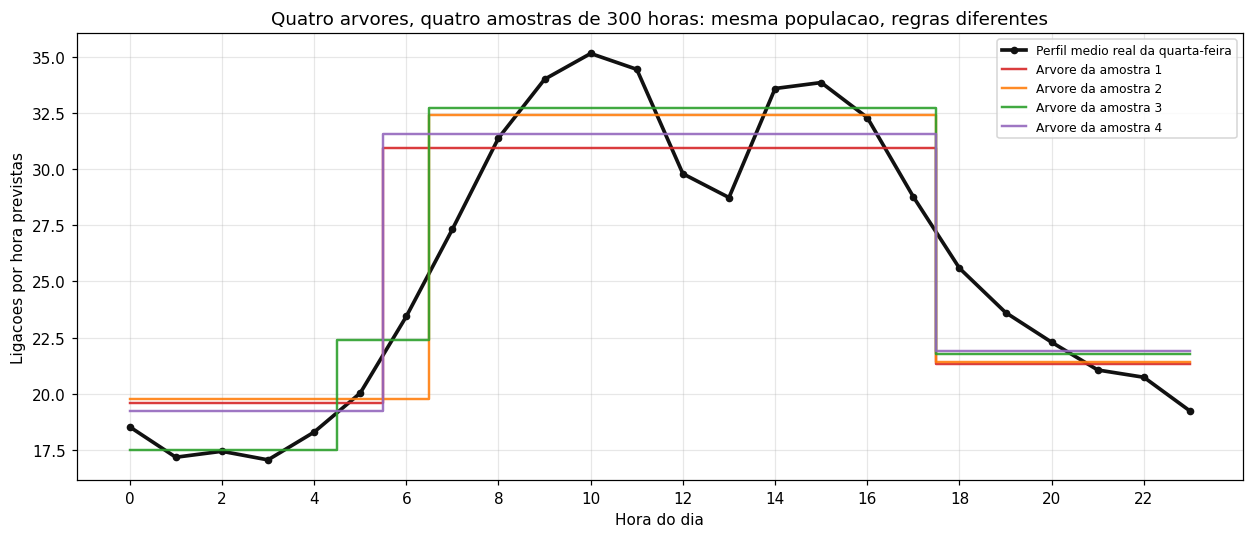

In [13]:
g = np.random.default_rng(3)
fig, ax = plt.subplots(figsize=(11.5, 5))
ax.plot(perfil_real.index, perfil_real.values, color="#111111", lw=2.4, marker="o", ms=4,
        label="Perfil medio real da quarta-feira")

for k, cor in enumerate(["#d62728", "#ff7f0e", "#2ca02c", "#9467bd"]):
    sorteio = g.integers(0, len(X_treino), 300)
    arv = DecisionTreeRegressor(max_depth=2, random_state=SEMENTE).fit(
        X_treino.iloc[sorteio], y_treino.iloc[sorteio])
    t = arv.tree_
    raiz = f"{X_treino.columns[t.feature[0]]} <= {t.threshold[0]:.1f}"
    filho_esq = X_treino.columns[t.feature[t.children_left[0]]]
    print(f"Amostra {k + 1}: raiz -> {raiz:22s} | 2a pergunta a esquerda -> {filho_esq}")
    ax.step(np.arange(24), arv.predict(cenario), where="mid", lw=1.6, color=cor, alpha=0.9,
            label=f"Arvore da amostra {k + 1}")

ax.set_title("Quatro arvores, quatro amostras de 300 horas: mesma populacao, regras diferentes")
ax.set_xlabel("Hora do dia"); ax.set_ylabel("Ligacoes por hora previstas")
ax.set_xticks(range(0, 24, 2)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Lendo o resultado.** As quatro árvores foram treinadas com dados vindos da **mesma** operação, mudando apenas quais 300 horas foram sorteadas. O resultado impresso mostra que a raiz oscila entre `hora <= 5.5` e `hora <= 6.5`, e a segunda pergunta muda de variável: em três amostras a árvore pergunta sobre `eh_fim_semana` e em uma delas volta a perguntar sobre `hora`. São **modelos com regras diferentes** ajustados ao mesmo fenômeno.
>
> No gráfico, as quatro escadas coloridas **não coincidem**: os patamares ficam em alturas diferentes e as quebras acontecem em horas diferentes. Se cada uma dessas árvores fosse levada a uma reunião, produziria uma recomendação de escala diferente.
>
> E aqui está a observação que abre a próxima seção, porque o gráfico contém **dois tipos diferentes de erro**. A **diferença entre as quatro escadas** vem apenas de qual amostra foi sorteada: é **variância**, e é justamente o tipo de erro que se cancela quando tiramos a média de muitos modelos. Já o fato de **todas** elas achatarem o pico das 10h e superestimarem o começo da noite é outra coisa: é **viés**, o erro que sobra porque o modelo é simples demais (profundidade 2), e esse a média **não** corrige.
>
> Guarde essa distinção, porque ela organiza o resto do curso: o **bagging**, na próxima seção, ataca a variância tirando a média de muitas árvores; o **boosting**, das Seções 6.2 e 7, ataca o viés treinando cada árvore para corrigir o erro que sobrou.


## 6.1 Bagging: a média de muitas árvores

**Bagging** é a abreviação de _bootstrap aggregating_, e o nome descreve o método em duas palavras.

**Bootstrap** é a técnica de gerar uma nova amostra de treino do mesmo tamanho da original, **sorteando com reposição**. Como o sorteio é com reposição, algumas horas entram duas ou três vezes e outras não entram nenhuma. Na prática, cada amostra bootstrap contém cerca de **63% das observações originais** (o restante são repetições), e as aproximadamente **37% que ficaram de fora** têm um nome e uma utilidade que veremos adiante: são as observações **out-of-bag**.

**Aggregating** é combinar as previsões, e em regressão isso quer dizer tirar a **média simples**:

$$ \hat{y}_{\text{bagging}}(x) = \frac{1}{K} \sum_{k=1}^{K} \hat{y}\_k(x) $$

O ponto teórico é o seguinte. Se as $K$ árvores fossem **perfeitamente independentes** e cada uma tivesse variância $\sigma^2$, a variância da média seria $\sigma^2 / K$. Na prática elas não são independentes, porque compartilham a maior parte dos dados, então a redução é menor do que $1/K$; mas ela é real e é grande. E o mais importante: o **viés** da média é aproximadamente o mesmo de uma árvore individual. Ou seja, o bagging **reduz variância praticamente de graça**, e é por isso que ele combina tão bem com árvores profundas, que são justamente modelos de baixo viés e alta variância.

Vamos implementar o bagging na mão, uma árvore por vez, e acompanhar o erro de teste caindo à medida que árvores são acrescentadas.


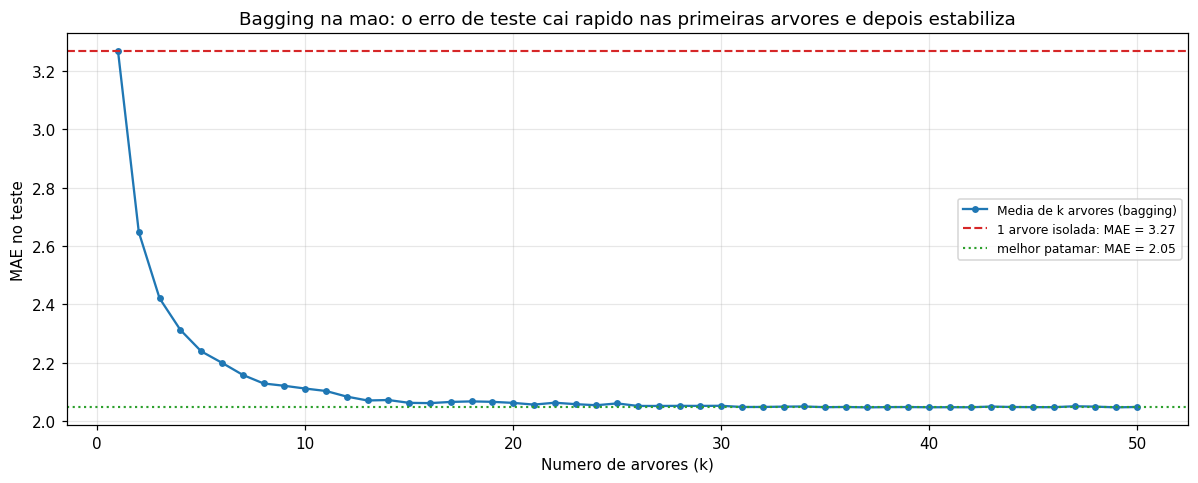

  k =   1 arvores  ->  MAE no teste = 3.268
  k =   2 arvores  ->  MAE no teste = 2.648
  k =   3 arvores  ->  MAE no teste = 2.421
  k =   5 arvores  ->  MAE no teste = 2.239
  k =  10 arvores  ->  MAE no teste = 2.112
  k =  20 arvores  ->  MAE no teste = 2.063
  k =  30 arvores  ->  MAE no teste = 2.053
  k =  50 arvores  ->  MAE no teste = 2.049


In [14]:
g = np.random.default_rng(SEMENTE)
soma_previsoes = np.zeros(len(X_teste))
curva_mae, K_MAX = [], 50

for k in range(1, K_MAX + 1):
    sorteio = g.integers(0, len(X_treino), len(X_treino))       # bootstrap: com reposicao
    arv = DecisionTreeRegressor(random_state=SEMENTE + k).fit(   # arvore profunda, sem poda
        X_treino.iloc[sorteio], y_treino.iloc[sorteio])
    soma_previsoes += arv.predict(X_teste)
    curva_mae.append(metricas(y_teste, soma_previsoes / k)[0])   # media das k arvores

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(range(1, K_MAX + 1), curva_mae, marker="o", ms=3.5, color="#1f77b4",
        label="Media de k arvores (bagging)")
ax.axhline(curva_mae[0], color="#d62728", ls="--", lw=1.4,
           label=f"1 arvore isolada: MAE = {curva_mae[0]:.2f}")
ax.axhline(min(curva_mae), color="#2ca02c", ls=":", lw=1.4,
           label=f"melhor patamar: MAE = {min(curva_mae):.2f}")
ax.set_title("Bagging na mao: o erro de teste cai rapido nas primeiras arvores e depois estabiliza")
ax.set_xlabel("Numero de arvores (k)"); ax.set_ylabel("MAE no teste"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for k in [1, 2, 3, 5, 10, 20, 30, 50]:
    print(f"  k = {k:3d} arvores  ->  MAE no teste = {curva_mae[k - 1]:.3f}")

> **Lendo o gráfico.** A curva começa em **3,27** com uma única árvore profunda e sem poda, o pior ponto do gráfico, e cai depressa: **2,65** com 2 árvores, **2,24** com 5, **2,11** com 10, e estabiliza em torno de **2,05** a partir de umas 30 árvores.
>
> Vale apreciar o que aconteceu, porque é contraintuitivo. **Nenhuma** dessas árvores foi podada. Cada uma delas, individualmente, é um modelo sobreajustado, com folhas de uma única observação. Ainda assim, a média de 30 delas erra **37% menos** do que uma sozinha. O overfitting de cada árvore era, em boa parte, **ruído com sinal aleatório**, e ruído aleatório se cancela na média. O padrão real, que todas as árvores enxergam por igual, sobrevive.
>
> Repare no formato da curva: o ganho é enorme nas primeiras árvores e vira quase nada depois de 30. Isso é a lei de retornos decrescentes do bagging, e tem uma consequência prática direta: aumentar `n_estimators` **nunca piora** o modelo (diferente do que acontece com boosting), apenas custa mais tempo de treino. Por isso a recomendação usual é usar algumas centenas de árvores e não se preocupar mais com esse parâmetro.


### Random Forest: bagging com um segundo sorteio

O **Random Forest**, proposto por Breiman (2001), é o exemplo mais conhecido de bagging de árvores, e acrescenta um ingrediente ao que acabamos de implementar: além de sortear as **observações**, ele sorteia também as **features** candidatas em cada divisão. Quando um nó vai ser dividido, o algoritmo não considera todas as 10 colunas, apenas um subconjunto aleatório de tamanho `max_features`.

O motivo é sutil e importante. No bagging puro, se existe uma feature muito dominante (aqui, `hora`), **todas** as árvores tendem a começar perguntando por ela, e ficam parecidas entre si. Árvores parecidas erram juntas, e erros correlacionados **não se cancelam** na média. O sorteio de features força árvores diferentes a olhar o problema por ângulos diferentes, **descorrelacionando** os erros e permitindo que a média funcione melhor.

Duas notas práticas antes de rodar. Primeiro, no `RandomForestRegressor` do scikit-learn o padrão é `max_features=1.0`, isto é, **todas** as features, o que tecnicamente equivale a bagging puro; para regressão essa é a recomendação usual, e o sorteio mais agressivo é o padrão em classificação. Segundo, o Random Forest oferece de graça uma estimativa de erro fora da amostra: como cerca de 37% das observações ficam de fora de cada bootstrap, é possível avaliar cada observação usando **apenas as árvores que não a viram**. Esse é o escore **out-of-bag** (`oob_score`), uma validação embutida no próprio treinamento.


In [15]:
from sklearn.ensemble import RandomForestRegressor

floresta = RandomForestRegressor(
    n_estimators=300,        # numero de arvores
    min_samples_leaf=2,      # pre-poda leve
    max_features=1.0,        # todas as features candidatas em cada divisao (padrao em regressao)
    oob_score=True,          # calcula o escore out-of-bag
    random_state=SEMENTE,
    n_jobs=-1,
)
floresta.fit(X_treino, y_treino)

mae_rf, rmse_rf, mape_rf = metricas(y_teste, floresta.predict(X_teste))
arvore_ref = DecisionTreeRegressor(max_depth=11, random_state=SEMENTE).fit(X_treino, y_treino)
mae_arv = metricas(y_teste, arvore_ref.predict(X_teste))[0]

print(f"Random Forest com {floresta.n_estimators} arvores")
print(f"  MAE  no teste : {mae_rf:.3f} ligacoes por hora")
print(f"  RMSE no teste : {rmse_rf:.3f}")
print(f"  MAPE no teste : {mape_rf:.2f}%")
print(f"  R2 out-of-bag : {floresta.oob_score_:.4f}  (validacao embutida, sem tocar no teste)")
print()
print(f"Melhor arvore isolada (max_depth=11) : MAE {mae_arv:.3f}")
print(f"Ganho do ensemble                    : {100 * (mae_arv - mae_rf) / mae_arv:.1f}% de reducao no MAE")

Random Forest com 300 arvores
  MAE  no teste : 2.028 ligacoes por hora
  RMSE no teste : 2.567
  MAPE no teste : 7.70%
  R2 out-of-bag : 0.9330  (validacao embutida, sem tocar no teste)

Melhor arvore isolada (max_depth=11) : MAE 2.177
Ganho do ensemble                    : 6.8% de reducao no MAE


> **Lendo o resultado.** O Random Forest erra, em média, **2,03 ligações por hora** em um período de teste cuja média é 28,2, o que dá um **MAPE de 7,7%**. Como referência de patamar, a apostila menciona na Seção 12.2 que os estudos revisados relatam MAPE entre 8% e 15% para previsão de chegadas hospitalares, então estamos em uma faixa perfeitamente respeitável.
>
> A comparação com a melhor árvore isolada que conseguimos (`max_depth=11`, escolhida com a curva da Seção 5.3) mostra **6,8% de redução no MAE**. Vale notar de onde vem esse ganho: não de um modelo mais esperto, e sim de **muitos modelos medianos combinados**. O Random Forest não exigiu de nós nenhuma busca cuidadosa de profundidade; ele é robusto quase na configuração padrão, e essa baixa sensibilidade a hiperparâmetros é uma das razões da sua popularidade.
>
> Por último, o **R2 out-of-bag de 0,933**. Esse número foi calculado sem tocar em novembro e dezembro: cada hora de treino foi prevista somente pelas árvores que não a sortearam. Ele é uma estimativa honesta de generalização obtida **durante** o treinamento, e é especialmente útil quando os dados são escassos e separar um conjunto de validação sairia caro.


In [16]:
comparacao_mf = []
for mf in [0.3, 0.5, 0.7, 1.0]:
    r = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, max_features=mf,
                              random_state=SEMENTE, n_jobs=-1).fit(X_treino, y_treino)
    m = metricas(y_teste, r.predict(X_teste))
    comparacao_mf.append({"max_features": mf,
                          "features por divisao": int(np.ceil(mf * X_treino.shape[1])),
                          "MAE": round(m[0], 3), "RMSE": round(m[1], 3), "MAPE (%)": round(m[2], 2)})

pd.DataFrame(comparacao_mf)

,max_features,features por divisao,MAE,RMSE,MAPE (%)
0,0.3,3,2.344,2.957,8.84
1,0.5,5,2.164,2.744,8.08
2,0.7,7,2.122,2.676,7.97
3,1.0,10,2.028,2.568,7.70


> **Lendo a tabela.** Aqui o resultado contraria a intuição de que "mais aleatoriedade é sempre melhor", e vale entender por quê. O MAE **melhora de forma monótona** conforme aumentamos `max_features`: 2,34 com 3 features por divisão, 2,16 com 5, 2,12 com 7 e **2,03 com todas as 10**.
>
> A explicação está na estrutura desta série. A feature `hora` sozinha explica 34% da variância e nenhuma outra passa de 6%. Quando forçamos a árvore a escolher entre um punhado de features sorteadas, muitas vezes `hora` simplesmente **não está no sorteio**, e a árvore é obrigada a fazer uma pergunta ruim naquele nó. O prejuízo de enfraquecer cada árvore individual supera o benefício de descorrelacioná-las.
>
> A lição geral é que `max_features` controla um **balanço**: valores baixos descorrelacionam mais e enfraquecem cada árvore; valores altos fazem o oposto. Séries com **um preditor dominante** (como esta) preferem valores altos; bases com **muitas features de força parecida e correlacionadas entre si** ganham com valores baixos. É um parâmetro para testar, não para chutar, e o teste custa poucos segundos.


### Importância das variáveis: o que a floresta aprendeu

Uma árvore registra, em cada divisão, **quanta variância aquela pergunta eliminou**. Somando essas reduções por feature ao longo de todas as árvores e normalizando para somar 1, obtemos a **importância** de cada variável. É um raio-X do que o modelo considerou relevante, e uma das saídas mais valiosas para conversar com a gestão.


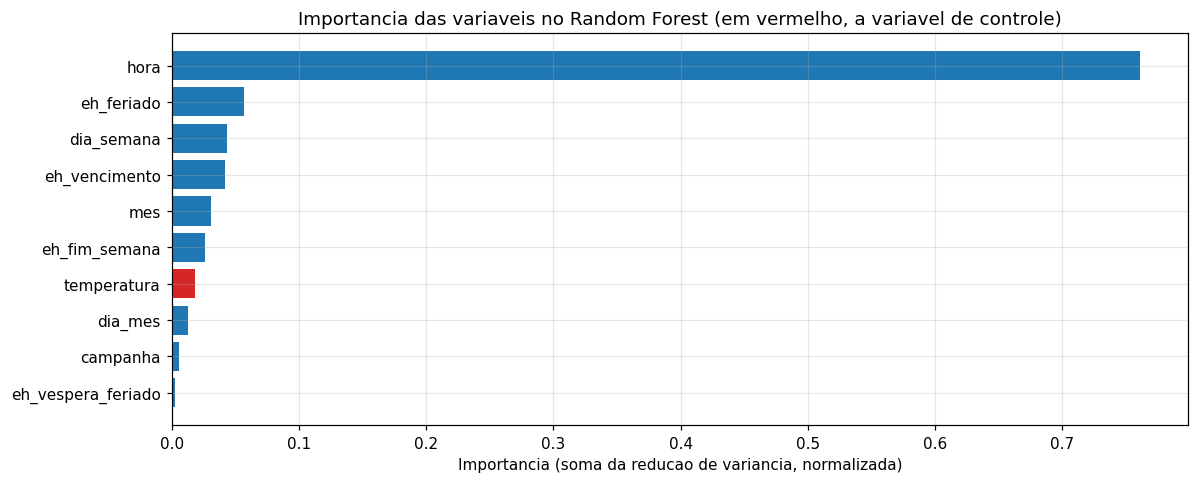

hora                  76.07
eh_feriado             5.69
dia_semana             4.34
eh_vencimento          4.18
mes                    3.12
eh_fim_semana          2.62
temperatura            1.85
dia_mes                1.27
campanha               0.61
eh_vespera_feriado     0.26


In [17]:
importancia = pd.Series(floresta.feature_importances_, index=X_treino.columns).sort_values()

fig, ax = plt.subplots(figsize=(11, 4.5))
cores = ["#d62728" if nome == "temperatura" else "#1f77b4" for nome in importancia.index]
ax.barh(importancia.index, importancia.values, color=cores)
ax.set_title("Importancia das variaveis no Random Forest (em vermelho, a variavel de controle)")
ax.set_xlabel("Importancia (soma da reducao de variancia, normalizada)")
plt.tight_layout(); plt.show()

print((importancia.sort_values(ascending=False) * 100).round(2).to_string())

> **Lendo o gráfico.** O ranking é dominado por **`hora`, com 76,1%** da importância total, o que confirma tudo que vimos desde a Seção 5.2. Depois vêm **`eh_feriado` (5,7%)**, **`dia_semana` (4,3%)**, **`eh_vencimento` (4,2%)**, `mes` (3,1%) e `eh_fim_semana` (2,6%).
>
> A barra vermelha é o teste de sanidade da aula: a variável de controle **`temperatura`**, que sabemos não ter efeito nenhum, ficou com **1,9%**, entre as últimas da fila. O modelo, corretamente, quase não a usou. E note que não ficou em zero exato: features contínuas oferecem muitos limiares de corte possíveis, então alguma quantidade de ruído sempre é aproveitada por acaso. Isso é uma limitação conhecida da importância por redução de variância, que tem viés a favor de variáveis contínuas e de alta cardinalidade. Quando a decisão for realmente importante, vale confirmar com **importância por permutação** (`sklearn.inspection.permutation_importance`).
>
> A leitura mais delicada é a de **`campanha` (0,6%)**, quase no fim da lista. Seria um erro concluir que campanhas de comunicação não afetam o call center. Elas afetam, e bastante: acrescentam 9 ligações por hora, mas **somente em 12 dias do ano e apenas entre 9h e 13h**, o que é uma fração minúscula das 8.760 horas. A importância é uma medida **global**: ela responde "quanto essa variável ajudou no conjunto todo", não "quanto ela importa quando está ativa". Para a segunda pergunta, o instrumento certo é olhar o erro **condicionado** àquele subgrupo, e é o que fazemos a seguir.


## Avaliação final: comparando todos os modelos (Seção 12)

Chegou a hora de colocar tudo na mesma mesa, no mesmo período de teste, com as três métricas da Seção 12 da apostila:

- **MAE** (_Mean Absolute Error_), o erro médio em ligações por hora. É a métrica mais fácil de comunicar à gestão: "erramos, em média, tantas ligações por hora".
- **RMSE** (_Root Mean Squared Error_), que eleva o erro ao quadrado antes de somar e por isso **pune erros grandes** com mais severidade. Importa quando um único pico mal previsto causa fila e abandono de chamada.
- **MAPE** (_Mean Absolute Percentage Error_), o erro em percentual do valor real, que permite comparar séries de escalas diferentes.

Incluímos dois pontos de referência que não são modelos de Machine Learning, e essa comparação é obrigatória em qualquer projeto sério:

- a **média histórica global**, o input estático que a simulação usaria sem nenhum modelo de previsão;
- a **tabela média de dia da semana por hora**, ou seja, "olhe o histórico da mesma hora da mesma terça-feira e use aquela média". É uma regra simples, que qualquer planilha faz, e é surpreendentemente competitiva. Se um modelo sofisticado não bater essa referência, ele não se justifica.


In [18]:
# Referencia 1: media historica global (input estatico)
prev_media = np.full(len(y_teste), y_treino.mean())

# Referencia 2: tabela media de dia da semana x hora, calculada apenas no treino
tabela = y_treino.groupby([X_treino["dia_semana"], X_treino["hora"]]).mean()
prev_tabela = np.array([tabela.loc[(d, h)] for d, h in zip(X_teste["dia_semana"], X_teste["hora"])])

arvore_d4 = DecisionTreeRegressor(max_depth=4, random_state=SEMENTE).fit(X_treino, y_treino)
arvore_livre = DecisionTreeRegressor(random_state=SEMENTE).fit(X_treino, y_treino)

modelos = [
    ("Media historica global (input estatico)", prev_media),
    ("Tabela media dia da semana x hora", prev_tabela),
    ("Arvore rasa (max_depth=4)", arvore_d4.predict(X_teste)),
    ("Arvore sem limite de profundidade", arvore_livre.predict(X_teste)),
    ("Arvore podada (max_depth=11)", arvore_ref.predict(X_teste)),
    ("Random Forest (300 arvores)", floresta.predict(X_teste)),
]

placar = pd.DataFrame([
    {"modelo": nome, "MAE": round(m[0], 3), "RMSE": round(m[1], 3), "MAPE (%)": round(m[2], 2)}
    for nome, prev in modelos for m in [metricas(y_teste, prev)]
])
placar["ganho vs input estatico"] = (
    (100 * (placar["MAE"].iloc[0] - placar["MAE"]) / placar["MAE"].iloc[0]).round(1).astype(str) + "%")
placar

,modelo,MAE,RMSE,MAPE (%),ganho vs input estatico
0,Media historica global (input estatico),6.959,8.593,27.68,0.0%
1,Tabela media dia da semana x hora,3.608,4.579,14.76,48.2%
2,Arvore rasa (max_depth=4),3.540,4.410,12.65,49.1%
3,Arvore sem limite de profundidade,2.397,3.074,9.25,65.6%
4,Arvore podada (max_depth=11),2.177,2.768,8.43,68.7%
5,Random Forest (300 arvores),2.028,2.567,7.70,70.9%


> **Lendo a tabela.** Todas as colunas seguem a regra "menor é melhor", e as seis linhas contam a aula inteira em números.
>
> - A **média histórica global** erra **6,96 ligações por hora** (MAPE de 27,7%). É o retrato de dimensionar a central por uma taxa média fixa: no pico da manhã falta gente, na madrugada sobra.
> - A **tabela dia por hora** derruba o erro para **3,61** (MAPE 14,8%), menos da metade. Fica registrado: uma boa referência simples resolve boa parte do problema, e é contra ela que os modelos precisam competir.
> - A **árvore rasa** (`max_depth=4`) chega a **3,54**, praticamente empatada com a tabela. Com 16 folhas ela ainda não tem resolução para superar uma regra de bom senso.
> - A **árvore sem limite** melhora para **2,40**, mas é justamente o modelo que memorizou o treino, como vimos na Seção 5.3.
> - A **árvore podada** (`max_depth=11`) alcança **2,18** com MAPE de 8,4%: mesma família, mesma base, apenas com a complexidade sob controle.
> - O **Random Forest** fecha em **2,03** de MAE, **2,57** de RMSE e **7,7%** de MAPE, o melhor resultado em todas as três métricas, uma redução de **71%** no erro em relação ao input estático.
>
> Observe que o RMSE do Random Forest (2,57) é proporcionalmente mais baixo do que o das árvores isoladas. Como o RMSE castiga erros grandes, isso indica que a floresta não só erra menos em média, como comete **menos erros graves**, o que é precisamente o efeito esperado de tirar a média de muitas árvores: os erros extremos de cada uma se cancelam.


In [19]:
mascara_feriado = X_teste["eh_feriado"].values == 1
mascara_campanha = ((X_teste["campanha"].values == 1) &
                    (X_teste["hora"].values >= 9) & (X_teste["hora"].values <= 13))
mascara_normal = (~mascara_feriado) & (X_teste["campanha"].values == 0)

linhas = []
for nome, prev in [("Tabela dia x hora", prev_tabela),
                   ("Arvore podada (d=11)", arvore_ref.predict(X_teste)),
                   ("Random Forest", floresta.predict(X_teste))]:
    linhas.append({
        "modelo": nome,
        "MAE horas normais": round(metricas(y_teste[mascara_normal], prev[mascara_normal])[0], 2),
        "MAE em feriados": round(metricas(y_teste[mascara_feriado], prev[mascara_feriado])[0], 2),
        "MAE na campanha (9h-13h)": round(metricas(y_teste[mascara_campanha], prev[mascara_campanha])[0], 2),
    })

print("Volume real medio em feriado          :", round(float(y_teste[mascara_feriado].mean()), 1))
print("  previsto pela tabela dia x hora     :", round(float(prev_tabela[mascara_feriado].mean()), 1))
print("  previsto pelo Random Forest         :", round(float(floresta.predict(X_teste)[mascara_feriado].mean()), 1))
print()
print("Volume real medio na campanha (9h-13h):", round(float(y_teste[mascara_campanha].mean()), 1))
print("  previsto pela tabela dia x hora     :", round(float(prev_tabela[mascara_campanha].mean()), 1))
print("  previsto pelo Random Forest         :", round(float(floresta.predict(X_teste)[mascara_campanha].mean()), 1))
print()
pd.DataFrame(linhas)

Volume real medio em feriado          : 16.8
  previsto pela tabela dia x hora     : 24.9
  previsto pelo Random Forest         : 15.1

Volume real medio na campanha (9h-13h): 40.5
  previsto pela tabela dia x hora     : 33.2
  previsto pelo Random Forest         : 35.6



,modelo,MAE horas normais,MAE em feriados,MAE na campanha (9h-13h)
0,Tabela dia x hora,3.25,8.14,7.64
1,Arvore podada (d=11),2.08,3.14,4.82
2,Random Forest,1.95,2.94,4.85


> **Lendo o resultado.** Este é o recorte que a importância global não mostrava, e é onde o valor das features operacionais aparece.
>
> **Feriados.** O volume real médio em hora de feriado é de **16,8 ligações**. A tabela dia por hora prevê **24,9**, porque ela não tem a menor ideia do que é um feriado: para ela, 15 de novembro é apenas um sábado qualquer. O Random Forest prevê **15,1**, muito perto do real. O MAE em feriados cai de **8,14 para 2,94**, uma redução de 64%. Traduzido para a operação: são atendentes escalados para um dia que não vai acontecer.
>
> **Campanhas.** O real médio entre 9h e 13h em dia de campanha é de **40,5 ligações por hora**. A tabela prevê **33,2** e o Random Forest prevê **35,6**, com MAE caindo de 7,64 para 4,85. Aqui o modelo **melhorou, mas ficou longe do ideal**, e vale ser honesto sobre a razão: só existiam **duas janelas de campanha** no período de treino, o equivalente a 8 dias. É pouquíssima evidência para o modelo aprender a magnitude do efeito com segurança. Ele aprendeu a **direção** (sabe que campanha aumenta o volume) mas subestima o tamanho.
>
> Essa é uma lição que vale mais do que qualquer hiperparâmetro: **eventos raros exigem histórico de eventos raros**. Nenhum algoritmo compensa a ausência de exemplos. Na operadora, isso significa registrar de forma estruturada as datas de disparo de campanha, de mudança de rede credenciada e de alterações de regra, para que a base de treino contenha essas ocorrências. É trabalho de governança de dados, e não de modelagem, mas é ele que define o teto do modelo.


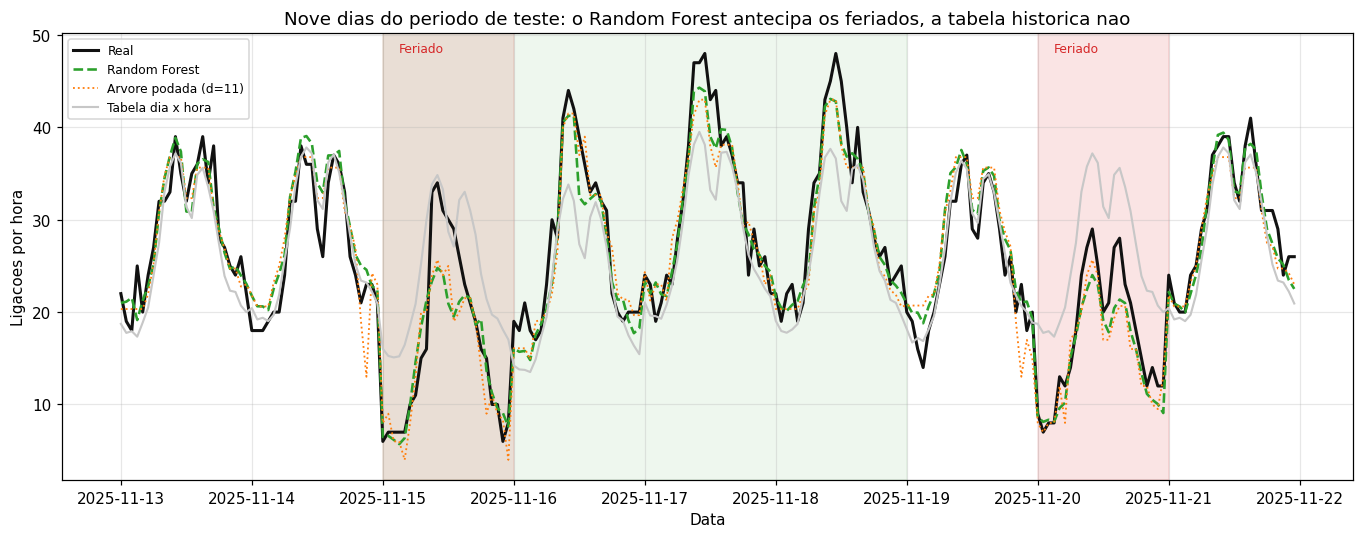

In [20]:
JANELA = slice("2025-11-13", "2025-11-21")   # contem feriado (15 e 20/11) e a janela de campanha

real = y_teste.loc[JANELA]
prev_rf = pd.Series(floresta.predict(X_teste.loc[JANELA]), index=real.index)
prev_arv = pd.Series(arvore_ref.predict(X_teste.loc[JANELA]), index=real.index)
prev_tab = pd.Series(prev_tabela, index=y_teste.index).loc[JANELA]

fig, ax = plt.subplots(figsize=(12.5, 5))
ax.plot(real.index, real.values, color="#111111", lw=2.0, label="Real")
ax.plot(prev_rf.index, prev_rf.values, color="#2ca02c", lw=1.7, ls="--", label="Random Forest")
ax.plot(prev_arv.index, prev_arv.values, color="#ff7f0e", lw=1.2, ls=":", label="Arvore podada (d=11)")
ax.plot(prev_tab.index, prev_tab.values, color="#c7c7c7", lw=1.4, label="Tabela dia x hora")

for d, etiqueta in [("2025-11-15", "Feriado"), ("2025-11-20", "Feriado")]:
    ax.axvspan(pd.Timestamp(d), pd.Timestamp(d) + pd.Timedelta(days=1), color="#d62728", alpha=0.12)
    ax.text(pd.Timestamp(d) + pd.Timedelta(hours=3), ax.get_ylim()[1] * 0.96, etiqueta,
            fontsize=8, color="#d62728")
ax.axvspan(pd.Timestamp("2025-11-15"), pd.Timestamp("2025-11-19"), color="#2ca02c", alpha=0.08)

ax.set_title("Nove dias do periodo de teste: o Random Forest antecipa os feriados, a tabela historica nao")
ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por hora"); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

> **Lendo o gráfico.** Nove dias de novembro, hora a hora, com o real em preto. As faixas vermelhas marcam os dois feriados (15 e 20 de novembro) e a faixa verde clara cobre a janela de campanha.
>
> A linha **cinza** (tabela histórica) mostra o problema com clareza: nos dois feriados ela mantém as ondas diárias na altura de sempre, **muito acima** da curva preta que despencou. É o erro de escalar equipe para um dia que não vem.
>
> A linha **verde** (Random Forest) acompanha a queda dos feriados, porque tem a coluna `eh_feriado` e aprendeu o que fazer com ela. Nos dias comuns, ela também reproduz o formato do dia com fidelidade, incluindo o vale do almoço.
>
> A linha **laranja pontilhada** (árvore isolada podada) segue o mesmo caminho geral, mas de forma **mais irregular**, com pequenos saltos onde a floresta é suave. Essa é a diferença entre uma escada única e a média de 300 escadas ligeiramente diferentes: a média suaviza os degraus e, no agregado, erra menos.


### Laboratório interativo: monte a sua floresta

Agora é a sua vez. Os três controles são os hiperparâmetros que realmente importam em um Random Forest:

- **`n_estimators`**: quantas árvores. Comece em 1 (é uma árvore isolada) e vá subindo. Observe que o erro cai rápido no começo e depois **para de cair**, sem nunca piorar de verdade.
- **`max_depth`**: profundidade de cada árvore. Diferente da árvore isolada, aqui você pode ser generoso: árvores profundas dentro de uma floresta grande costumam funcionar bem, porque a média cuida da variância. Compare `max_depth=4` com `max_depth=20` e veja qual generaliza melhor.
- **`min_samples_leaf`**: o freio contra folhas construídas sobre pouquíssimas observações.

O título mostra o MAE de treino, o MAE de teste e o R2 out-of-bag, para você comparar as três leituras ao mesmo tempo.


In [21]:
try:
    from ipywidgets import interact, IntSlider, SelectionSlider
    _INTERATIVO2 = True
except ImportError:
    _INTERATIVO2 = False

def laboratorio_floresta(n_estimators=100, max_depth=20, min_samples_leaf=2):
    modelo = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                   min_samples_leaf=min_samples_leaf, oob_score=True,
                                   random_state=SEMENTE, n_jobs=-1).fit(X_treino, y_treino)
    mae_tr = metricas(y_treino, modelo.predict(X_treino))[0]
    mae_te, _, mape_te = metricas(y_teste, modelo.predict(X_teste))

    r = y_teste.loc[SEMANA]
    p = pd.Series(modelo.predict(X_teste.loc[SEMANA]), index=r.index)

    fig, ax = plt.subplots(figsize=(11.5, 4.5))
    ax.plot(r.index, r.values, color="#111111", lw=1.7, label="Real")
    ax.plot(p.index, p.values, color="#2ca02c", lw=1.7, ls="--", label="Random Forest")
    ax.set_title(f"{n_estimators} arvores, max_depth={max_depth}, min folha={min_samples_leaf}   |   "
                 f"MAE treino={mae_tr:.2f}   MAE teste={mae_te:.2f}   "
                 f"MAPE={mape_te:.1f}%   R2 oob={modelo.oob_score_:.3f}")
    ax.set_xlabel("Data (semana do periodo de teste)"); ax.set_ylabel("Ligacoes por hora")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

if _INTERATIVO2:
    interact(
        laboratorio_floresta,
        n_estimators=SelectionSlider(options=[1, 2, 5, 10, 25, 50, 100, 200, 300],
                                     value=100, description="n_estimators"),
        max_depth=SelectionSlider(options=[2, 4, 6, 8, 11, 15, 20, 30], value=20, description="max_depth"),
        min_samples_leaf=IntSlider(value=2, min=1, max=50, step=1, description="min folha"),
    )
else:
    print("ipywidgets indisponivel; exibindo dois cenarios estaticos.")
    laboratorio_floresta(1, 20, 2)
    laboratorio_floresta(300, 20, 2)

interactive(children=(SelectionSlider(description='n_estimators', index=6, options=(1, 2, 5, 10, 25, 50, 100, …

> **O que observar.** Na configuração padrão, o MAE de teste fica em torno de 2,03 e o R2 out-of-bag em 0,93. Faça três experimentos:
>
> 1. **Reduza `n_estimators` para 1.** O erro sobe visivelmente e a curva verde fica cheia de saltos: você está olhando uma árvore isolada, sem o benefício da média.
> 2. **Compare `max_depth=4` com `max_depth=20`.** Na árvore isolada, profundidade 20 era sinônimo de memorização; aqui, ela é claramente melhor do que 4. Esse contraste é a essência do bagging: ele **compra** o direito de usar modelos individualmente sobreajustados.
> 3. **Suba `min_samples_leaf` para 30 ou 50.** O MAE de treino sobe, sinal de que o modelo está mais restrito, e o de teste muda pouco. Compare também com o R2 out-of-bag, que se move na mesma direção do MAE de teste **sem nunca ter visto** novembro e dezembro. É a evidência de que a validação embutida funciona.


## Síntese, limitações e próximo passo

Esta aula trocou a lente. Nos módulos anteriores, a série era o objeto de estudo; aqui ela virou **uma tabela**, e o modelo passou a aprender por perguntas encadeadas em vez de por coeficientes. O caminho que percorremos, com números:

| Etapa                   | O que aprendemos                                                   | Resultado no teste |
| ----------------------- | ------------------------------------------------------------------ | ------------------ |
| Input estático          | a média histórica ignora hora, dia e calendário                    | MAE 6,96           |
| Regra de bom senso      | a tabela dia por hora resolve a sazonalidade, mas não o calendário | MAE 3,61           |
| Árvore isolada sem poda | erro zero no treino e memorização do ruído                         | MAE 2,40           |
| Árvore isolada podada   | `max_depth` e `min_samples_leaf` controlam o overfitting           | MAE 2,18           |
| Random Forest           | bagging cancela o ruído de muitas árvores instáveis                | **MAE 2,03**       |

**Os quatro conceitos para levar da aula:**

1. **A divisão é escolhida por redução de variância.** Não há mágica: força bruta sobre features e limiares, e a pergunta que mais separa demanda alta de demanda baixa ganha o nó.
2. **Profundidade é resolução, e resolução em excesso é memorização.** Erro de treino zero é sintoma, não conquista. Sem avaliação fora da amostra não existe avaliação.
3. **Árvore isolada é instável.** Mudar um punhado de observações muda toda a estrutura de perguntas.
4. **Bagging transforma essa fraqueza em força.** A média de muitas árvores de alta variância cancela o ruído e preserva o sinal, quase de graça.

**Quando usar Random Forest na operadora:** é uma excelente linha de base de Machine Learning, difícil de configurar errado, que aceita muitas variáveis externas sem pré-processamento (não precisa normalizar, lida bem com features binárias), entrega importância de variáveis e traz validação out-of-bag embutida. Para volume de call center, solicitações de autorização prévia ou demanda por teleconsulta, ele deve ser o primeiro modelo de árvore a ser testado, exatamente porque estabelece um patamar honesto com pouco esforço.

**Limitações que apontam para os próximos módulos:**

- **Não extrapola.** A previsão de uma folha é a média de observações de treino, então nenhuma árvore prevê acima do máximo que já viu. Em séries com tendência de crescimento forte, isso viesa a previsão para baixo, e é uma das razões pelas quais se costuma modelar a tendência separadamente ou incluir features de tempo corrido.
- **Bagging reduz variância, não viés.** Todas as árvores são treinadas para o **mesmo** alvo, de forma independente e paralela. Nenhuma delas tenta corrigir o que as outras erraram, e existe um piso de erro que mais árvores não atravessam. Foi exatamente esse piso que vimos a curva do bagging encontrar em torno de 2,05 na Seção 6.1.
- **Eventos raros continuam difíceis.** Como o recorte de campanhas mostrou, poucas ocorrências no histórico limitam o quanto o modelo aprende, por mais sofisticado que seja.

**O próximo passo é o boosting.** Se o problema do bagging é que suas árvores são independentes, a pergunta natural é: e se cada nova árvore fosse treinada especificamente para **corrigir o erro que restou** das anteriores? Em vez de paralelas e independentes, árvores **sequenciais e dependentes**; em vez de reduzir variância, reduzir **viés**. É esse o mecanismo do **gradient boosting** (Seção 6.2), e é sobre ele que o **XGBoost** (Seção 7) e o **LightGBM** (Seção 8) são construídos. A árvore que estudamos hoje continua sendo o tijolo; o que muda é a forma de empilhar.

---

**Referências**

- Breiman, L.; Friedman, J. H.; Olshen, R. A.; Stone, C. J. (1984). _Classification and Regression Trees_. Wadsworth.
- Breiman, L. (2001). Random Forests. _Machine Learning_, v. 45, p. 5-32.
- Hastie, T.; Tibshirani, R.; Friedman, J. (2009). _The Elements of Statistical Learning_, 2ª edição. Springer.
- Porto, B. M.; Fogliatto, F. S. (2024). Enhanced forecasting of emergency department patient arrivals using feature engineering.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. _JMLR_, v. 12, p. 2825-2830.
